# JOILang Cloud Advisor Compression Analysis — by-config cloud-only edition

이 notebook은 기존 코드에 신규 `--cloud-only-advisor-compression` 같은 flag를 구현하지 않고도,
**quota / ratio 설정을 0으로 두어 cloudless compression fallback을 최대한 차단한 cloud-only-by-config 실험**을 수행하고 분석합니다.

분석 목표:

1. `cloudless` baseline
2. `cloud_advisor hybrid`: advisor + fallback
3. `cloud-only-by-config`: local compression quota/rate = 0, advisor compression quota만 활성
4. dataset evaluation feedback이 advisor prompt에 어떤 형태로 반영되는지 확인
5. cloud advisor prompt, GPT advisor model, proposal, accepted/rejected, before/after block/token 변화를 표로 확인
6. 논문/보고서용 CSV/MD artifact 저장

> 주의: 이 notebook은 "strict true cloud-only mode"를 새로 구현하지 않습니다.
> 대신 현재 코드에서 가능한 설정 기반 cloud-only 실험을 수행하고, artifact에서 `source="compression_fallback"`이 실제로 0인지 검증합니다.

In [4]:
# ============================================================
# Cell 1. Server/path configuration
# ============================================================

from pathlib import Path
from datetime import datetime
import os
import sys
import re
import json
import time
import math
import ast
import traceback
import subprocess
import pandas as pd
import numpy as np

# Change this only.
# Options: "A100_SET_B", "A6000_SET_A"
SERVER_PRESET = os.environ.get("JOI_SERVER_PRESET", "A6000_SET_A")

SERVER_CONFIGS = {
    "A100_SET_B": {
        "repo": Path("/root/llm/JOILang-Server"),
        # IMPORTANT: do not call resolve() on venv/conda python symlink.
        "python": Path("/root/llm/je/bin/python"),
        "local_model_base": Path("/root/llm/local_models"),
    },
    "A6000_SET_A": {
        "repo": Path("/home/mgjeong/Desktop/llm/JOILang-Server"),
        "python": Path("/home/mgjeong/miniconda3/envs/paper-gpu/bin/python3.10"),
        "local_model_base": Path("/home/mgjeong/Desktop/llm/local_models"),
    },
}

assert SERVER_PRESET in SERVER_CONFIGS, f"Unknown SERVER_PRESET: {SERVER_PRESET}"

REPO = SERVER_CONFIGS[SERVER_PRESET]["repo"]
PYTHON = SERVER_CONFIGS[SERVER_PRESET]["python"]
LOCAL_MODEL_BASE = SERVER_CONFIGS[SERVER_PRESET]["local_model_base"]

VERSION_DIR = REPO / "gpt_mg/version0_15_update20260413"
SCRIPT = VERSION_DIR / "scripts/run_ga_search.py"
RESULTS_ROOT = VERSION_DIR / "results"
SUMMARY_DIR = RESULTS_ROOT / "paper_artifacts" / "cloud_only_by_config"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIRS = {
    "qwen25_coder_7b": "qwen25_coder_7b",
    "llama31_8b": "llama31_8b",
    "qwen25_coder_14b": "qwen25_coder_14b",
    "phi35_mini": "phi35_mini",
    "gemma2_9b_it": "gemma2_9b_it",
}

MODEL_LIST_3 = [
    ("7B", "qwen25_coder_7b"),
    ("8B", "llama31_8b"),
    ("14B", "qwen25_coder_14b"),
]

RUN_MODES = [
    ("cloudless", False),
    ("cloud_advisor_hybrid", True),
    ("cloud_only_by_config", True),
]

print("=" * 120)
print("[CONFIG]")
print("=" * 120)
print("SERVER_PRESET:", SERVER_PRESET)
print("REPO:", REPO, REPO.exists())
print("VERSION_DIR:", VERSION_DIR, VERSION_DIR.exists())
print("SCRIPT:", SCRIPT, SCRIPT.exists())
print("PYTHON:", PYTHON, PYTHON.exists())
print("LOCAL_MODEL_BASE:", LOCAL_MODEL_BASE, LOCAL_MODEL_BASE.exists())
print("RESULTS_ROOT:", RESULTS_ROOT)
print("SUMMARY_DIR:", SUMMARY_DIR)

assert REPO.exists(), REPO
assert VERSION_DIR.exists(), VERSION_DIR
assert SCRIPT.exists(), SCRIPT
assert PYTHON.exists(), PYTHON
assert LOCAL_MODEL_BASE.exists(), LOCAL_MODEL_BASE

[CONFIG]
SERVER_PRESET: A6000_SET_A
REPO: /home/mgjeong/Desktop/llm/JOILang-Server True
VERSION_DIR: /home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413 True
SCRIPT: /home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py True
PYTHON: /home/mgjeong/miniconda3/envs/paper-gpu/bin/python3.10 True
LOCAL_MODEL_BASE: /home/mgjeong/Desktop/llm/local_models True
RESULTS_ROOT: /home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results
SUMMARY_DIR: /home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts/cloud_only_by_config


In [2]:
# ============================================================
# Cell 2. Environment verification
# ============================================================

def run_cmd(cmd, timeout=300, check=False, env=None):
    print("\nRUN:", " ".join(str(x) for x in cmd))
    p = subprocess.run(
        [str(x) for x in cmd],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        timeout=timeout,
        check=check,
        env=env,
    )
    print(p.stdout)
    return p.returncode, p.stdout

print("=" * 120)
print("[PYTHON ENV]")
print("=" * 120)

env_code = r'''
import sys
print("python:", sys.executable)
try:
    import torch
    print("torch:", getattr(torch, "__version__", "NO_VERSION_ATTR"))
    print("cuda:", torch.cuda.is_available())
    print("device_count:", torch.cuda.device_count())
    if torch.cuda.is_available() and torch.cuda.device_count() > 0:
        print("device0:", torch.cuda.get_device_name(0))
except Exception as e:
    print("torch_error:", repr(e))
try:
    import transformers
    print("transformers:", getattr(transformers, "__version__", "NO_VERSION_ATTR"))
except Exception as e:
    print("transformers_error:", repr(e))
'''
run_cmd([PYTHON, "-c", env_code], timeout=300)

print("=" * 120)
print("[NVIDIA-SMI]")
print("=" * 120)
try:
    run_cmd(["nvidia-smi"], timeout=60)
except Exception as e:
    print("[WARN] nvidia-smi failed:", repr(e))

print("=" * 120)
print("[OPENAI API KEY]")
print("=" * 120)
print("OPENAI_API_KEY exists:", bool(os.environ.get("OPENAI_API_KEY", "").strip()))

print("=" * 120)
print("[MODEL PATH CHECK]")
print("=" * 120)

rows = []
for model_key, dirname in MODEL_DIRS.items():
    p = LOCAL_MODEL_BASE / dirname
    rows.append({
        "model_key": model_key,
        "path": str(p),
        "exists": p.exists(),
        "config": (p / "config.json").exists(),
        "tokenizer": (p / "tokenizer.json").exists(),
        "index": (p / "model.safetensors.index.json").exists(),
        "safetensors_count": len(list(p.glob("*.safetensors"))) if p.exists() else 0,
    })
model_path_df = pd.DataFrame(rows)
display(model_path_df)

[PYTHON ENV]

RUN: /home/mgjeong/miniconda3/envs/paper-gpu/bin/python3.10 -c 
import sys
print("python:", sys.executable)
try:
    import torch
    print("torch:", getattr(torch, "__version__", "NO_VERSION_ATTR"))
    print("cuda:", torch.cuda.is_available())
    print("device_count:", torch.cuda.device_count())
    if torch.cuda.is_available() and torch.cuda.device_count() > 0:
        print("device0:", torch.cuda.get_device_name(0))
except Exception as e:
    print("torch_error:", repr(e))
try:
    import transformers
    print("transformers:", getattr(transformers, "__version__", "NO_VERSION_ATTR"))
except Exception as e:
    print("transformers_error:", repr(e))

python: /home/mgjeong/miniconda3/envs/paper-gpu/bin/python3.10
torch: 2.9.1+cu128
cuda: True
device_count: 2
device0: NVIDIA RTX A6000
transformers: 4.57.3

[NVIDIA-SMI]

RUN: nvidia-smi
Thu Jun 11 21:57:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 

,model_key,path,exists,config,tokenizer,index,safetensors_count
0,qwen25_coder_7b,/home/mgjeong/Desktop/llm/local_models/qwen25_...,True,True,True,True,4
1,llama31_8b,/home/mgjeong/Desktop/llm/local_models/llama31_8b,True,True,True,True,4
2,qwen25_coder_14b,/home/mgjeong/Desktop/llm/local_models/qwen25_...,True,True,True,True,6
3,phi35_mini,/home/mgjeong/Desktop/llm/local_models/phi35_mini,False,False,False,False,0
4,gemma2_9b_it,/home/mgjeong/Desktop/llm/local_models/gemma2_...,False,False,False,False,0


In [3]:
# ============================================================
# Cell 3. Source / flag verification
# ============================================================

help_rc, help_text = run_cmd([PYTHON, str(SCRIPT), "--help"], timeout=300)

supported_flags = set(re.findall(r"(--[a-zA-Z0-9][a-zA-Z0-9\-_]*)", help_text))
print("help rc:", help_rc)
print("supported flag count:", len(supported_flags))

# Existing strong compression flags expected in the current code.
EXISTING_STRONG_FLAGS = [
    "--compression-detpass-threshold",
    "--aggressive-compression-after-target",
    "--compression-child-quota",
    "--compression-child-ratio",
    "--advisor-compression-child-quota",
    "--advisor-prefer-compression-after-detpass",
    "--compression-token-reduction-target",
    "--compression-token-plateau-delta",
    "--allow-aggressive-compression",
    "--micro-compression-child-quota",
    "--micro-compression-child-ratio",
    "--block-compression-child-quota",
    "--block-compression-child-ratio",
    "--multi-block-compression-child-quota",
    "--multi-block-compression-child-ratio",
    "--global-budget-compression-child-quota",
    "--enable-block-token-breakdown",
    "--enable-multi-block-compression",
    "--min-compression-token-delta",
]

# These are NOT required for this by-config notebook, but we show whether strict implementation exists.
STRICT_CLOUD_ONLY_FLAGS = [
    "--cloud-only-advisor-compression",
    "--disable-compression-fallback",
    "--advisor-proposal-k",
    "--advisor-min-usable-compression-proposals",
    "--advisor-repair-invalid-proposals",
    "--advisor-repair-max-attempts",
    "--advisor-require-block-proposal-after-detpass",
    "--advisor-require-token-delta",
    "--advisor-disallow-genome-only-after-detpass",
    "--advisor-cloud-only-strict-schema",
    "--advisor-before-after-report",
    "--advisor-include-dataset-feedback",
    "--advisor-feedback-topk",
    "--advisor-feedback-max-failures-per-family",
    "--advisor-include-prompt-before-after-context",
    "--advisor-include-case-abc-sections",
    "--advisor-write-debug-prompt-sections",
]

flag_rows = []
for f in EXISTING_STRONG_FLAGS:
    flag_rows.append({"flag": f, "kind": "existing_strong", "supported": f in supported_flags})
for f in STRICT_CLOUD_ONLY_FLAGS:
    flag_rows.append({"flag": f, "kind": "strict_cloud_only_optional", "supported": f in supported_flags})

flag_df = pd.DataFrame(flag_rows)
display(flag_df)

missing_existing = flag_df[(flag_df["kind"] == "existing_strong") & (~flag_df["supported"])]["flag"].tolist()
if missing_existing:
    print("[WARN] Missing some strong-compression flags. Wrapper will skip unsupported flags:", missing_existing)
else:
    print("[OK] Existing strong compression flags are available.")

strict_available = all(f in supported_flags for f in STRICT_CLOUD_ONLY_FLAGS)
print("STRICT_CLOUD_ONLY_IMPLEMENTED:", strict_available)

advisor_feedback_path = VERSION_DIR / "scripts/advisor_feedback.py"
advisor_src = advisor_feedback_path.read_text(encoding="utf-8", errors="replace") if advisor_feedback_path.exists() else ""

sections = [
    "DATASET_EVALUATION_FEEDBACK",
    "CASE_A_MICRO_COMPRESSION",
    "CASE_B_THRESHOLD_BLOCK_COMPRESSION",
    "CASE_C_AGGRESSIVE_MULTI_GLOBAL_COMPRESSION",
    "STRICT_JSON_RESPONSE_SCHEMA",
    "PROMPT_TOKEN_BREAKDOWN",
    "BLOCK_TOKEN_BREAKDOWN",
    "compression_policy",
    "block_token_breakdown",
    "prompt_token_breakdown",
]

section_df = pd.DataFrame([{"section": s, "found": s in advisor_src} for s in sections])
display(section_df)

print("\n[MODE]")
print("This notebook uses cloud-only-by-config, so strict cloud-only flags are optional.")
print("Cloud-only-by-config means: local compression quotas/rates = 0, advisor compression quota > 0, then artifact gate checks fallback rows are actually 0.")


RUN: /home/mgjeong/miniconda3/envs/paper-gpu/bin/python3.10 /home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --help
usage: run_ga_search.py [-h] --profile PROFILE [--genome-json GENOME_JSON]
                        [--dataset DATASET] [--service-schema SERVICE_SCHEMA]
                        [--limit LIMIT] [--start-row START_ROW]
                        [--end-row END_ROW] [--category CATEGORY]
                        [--limit-per-category LIMIT_PER_CATEGORY]
                        [--population POPULATION] [--gens GENS]
                        [--crossover-rate CROSSOVER_RATE]
                        [--mutation-rate MUTATION_RATE] [--elites ELITES]
                        [--sample-size SAMPLE_SIZE]
                        [--cheap-eval-limit CHEAP_EVAL_LIMIT]
                        [--candidate-k CANDIDATE_K]
                        [--repair-attempts REPAIR_ATTEMPTS]
                        [--validation-size VALIDATION_SIZE] [

,flag,kind,supported
0,--compression-detpass-threshold,existing_strong,True
1,--aggressive-compression-after-target,existing_strong,True
2,--compression-child-quota,existing_strong,True
3,--compression-child-ratio,existing_strong,True
4,--advisor-compression-child-quota,existing_strong,True
5,--advisor-prefer-compression-after-detpass,existing_strong,True
6,--compression-token-reduction-target,existing_strong,True
7,--compression-token-plateau-delta,existing_strong,True
8,--allow-aggressive-compression,existing_strong,True
9,--micro-compression-child-quota,existing_strong,True


[OK] Existing strong compression flags are available.
STRICT_CLOUD_ONLY_IMPLEMENTED: False


,section,found
0,DATASET_EVALUATION_FEEDBACK,False
1,CASE_A_MICRO_COMPRESSION,False
2,CASE_B_THRESHOLD_BLOCK_COMPRESSION,False
3,CASE_C_AGGRESSIVE_MULTI_GLOBAL_COMPRESSION,False
4,STRICT_JSON_RESPONSE_SCHEMA,False
5,PROMPT_TOKEN_BREAKDOWN,False
6,BLOCK_TOKEN_BREAKDOWN,False
7,compression_policy,True
8,block_token_breakdown,True
9,prompt_token_breakdown,True



[MODE]
This notebook uses cloud-only-by-config, so strict cloud-only flags are optional.
Cloud-only-by-config means: local compression quotas/rates = 0, advisor compression quota > 0, then artifact gate checks fallback rows are actually 0.


In [6]:
# ============================================================
# Cell 4. run_ga_all_categories wrapper
# ============================================================

def _flag_supported(flag: str) -> bool:
    # If help parsing failed, allow known arguments; otherwise filter to avoid crashes.
    if supported_flags:
        return flag in supported_flags
    return True

def _add_arg(cmd, flag, value=None, is_bool=False):
    if not _flag_supported(flag):
        print(f"[SKIP unsupported flag] {flag}")
        return
    if is_bool:
        if bool(value):
            cmd.append(flag)
    else:
        if value is not None:
            cmd.extend([flag, str(value)])

def _model_env(model_key: str, mode_name: str):
    env = os.environ.copy()
    env["JOI_V15_LOCAL_MODEL_BASE_DIR"] = str(LOCAL_MODEL_BASE)
    if model_key in MODEL_DIRS:
        local_path = LOCAL_MODEL_BASE / MODEL_DIRS[model_key]
        if local_path.exists():
            env["JOI_V15_LOCAL_MODEL_NAME"] = str(local_path)
    env["TRANSFORMERS_OFFLINE"] = env.get("TRANSFORMERS_OFFLINE", "1")
    env["HF_HUB_OFFLINE"] = env.get("HF_HUB_OFFLINE", "1")
    env["TOKENIZERS_PARALLELISM"] = "false"
    return env

def _run_key_suffix(categories, limit_per_category, population, gens, model_key):
    cat_str = "".join(str(c) for c in categories)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    return f"cat{cat_str}_lpc{limit_per_category}_pop{population}_gens{gens}_{model_key}_{ts}"

def run_ga_all_categories(
    model_key: str = "qwen25_coder_14b",
    categories=(1,),
    limit_per_category=1,
    sample_size=1,
    validation_size=1,
    population=4,
    gens=3,
    target_detpass=90,
    base_prefix=None,
    use_advisor=False,
    mode_label=None,
    full_run=True,
    progress="verbose",
    timeout_sec=1200,
    retries=0,
    idle_timeout_sec=None,
    total_timeout_sec=None,

    advisor_model_key="gpt41_mini",
    advisor_trigger_mode="always",
    advisor_min_population_for_child=4,
    advisor_force_child_quota=True,
    use_mock_advisor=False,

    feedback_guided_mutation=True,
    enable_compression_mutation=True,
    enable_prompt_decompiler=True,
    enable_rendered_prompt_dedupe=True,
    enable_pareto_archive=True,
    enable_group_specialist_archives=True,

    compression_detpass_threshold=90,
    aggressive_compression_after_target=True,
    compression_child_quota=1,
    compression_child_ratio=0.25,
    advisor_compression_child_quota=1,
    advisor_prefer_compression_after_detpass=90,
    compression_token_reduction_target=0.15,
    compression_token_plateau_delta=1.0,
    allow_aggressive_compression=True,

    micro_compression_child_quota=1,
    micro_compression_child_ratio=0.25,
    block_compression_child_quota=1,
    block_compression_child_ratio=0.25,
    multi_block_compression_child_quota=1,
    multi_block_compression_child_ratio=0.25,
    global_budget_compression_child_quota=0,
    enable_block_token_breakdown=True,
    enable_multi_block_compression=True,
    enable_render_budget_compression=False,
    min_compression_token_delta=50,

    # by-config cloud-only convenience switch
    cloud_only_by_config=False,
):
    categories = tuple(categories)
    mode_name = mode_label or ("cloud_advisor" if use_advisor else "cloudless")
    if base_prefix is None:
        base_prefix = f"ga_{SERVER_PRESET}_{mode_name}"

    if cloud_only_by_config:
        use_advisor = True
        mode_name = mode_label or "cloud_only_by_config"
        compression_child_quota = 0
        compression_child_ratio = 0.0
        micro_compression_child_quota = 0
        micro_compression_child_ratio = 0.0
        block_compression_child_quota = 0
        block_compression_child_ratio = 0.0
        multi_block_compression_child_quota = 0
        multi_block_compression_child_ratio = 0.0
        global_budget_compression_child_quota = 0
        # advisor_compression_child_quota remains positive.

    out_dir = RESULTS_ROOT / f"{base_prefix}_{mode_name}_{_run_key_suffix(categories, limit_per_category, population, gens, model_key)}" / "ga_output"
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        str(PYTHON), "-u", str(SCRIPT),
        "--profile", "version0_15",
        "--model-key", model_key,
        "--target-detpass", str(target_detpass),
        "--llm-mode", "worker",
        "--population", str(population),
        "--gens", str(gens),
        "--min-generations", str(gens),
        "--max-generations", str(gens),
        "--sample-size", str(sample_size),
        "--validation-size", str(validation_size),
        "--cheap-eval-limit", "2",
        "--candidate-k", "1",
        "--repair-attempts", "0",
        "--det-profile", "strict",
        "--selection-mode", "redesign",
        "--fitness-mode", "phase_aware",
        "--mutation-mode", "cloudless_decompiler",
        "--category-balance-mode", "guard",
        "--token-penalty-mode", "hybrid",
        "--stop-controller-mode", "active",
        "--plateau-window", "1",
        "--disruptive-max-attempts", "1",
        "--reasoning-mutation-mode", "auto",
        "--intent-hint-mode", "auto",
        "--progress", progress,
        "--timeout-sec", str(timeout_sec),
        "--retries", str(retries),
        "--limit-per-category", str(limit_per_category),
        "--output-root", str(out_dir),
    ]

    for c in categories:
        cmd.extend(["--category", str(c)])

    _add_arg(cmd, "--full-run", full_run, is_bool=True)
    _add_arg(cmd, "--feedback-guided-mutation", feedback_guided_mutation, is_bool=True)
    _add_arg(cmd, "--enable-compression-mutation", enable_compression_mutation, is_bool=True)
    _add_arg(cmd, "--enable-prompt-decompiler", enable_prompt_decompiler, is_bool=True)
    _add_arg(cmd, "--enable-rendered-prompt-dedupe", enable_rendered_prompt_dedupe, is_bool=True)
    _add_arg(cmd, "--enable-pareto-archive", enable_pareto_archive, is_bool=True)
    _add_arg(cmd, "--enable-group-specialist-archives", enable_group_specialist_archives, is_bool=True)

    _add_arg(cmd, "--idle-timeout-sec", idle_timeout_sec)
    _add_arg(cmd, "--total-timeout-sec", total_timeout_sec)

    # Compression flags.
    _add_arg(cmd, "--compression-detpass-threshold", compression_detpass_threshold)
    _add_arg(cmd, "--compression-child-quota", compression_child_quota)
    _add_arg(cmd, "--compression-child-ratio", compression_child_ratio)
    _add_arg(cmd, "--advisor-compression-child-quota", advisor_compression_child_quota)
    _add_arg(cmd, "--advisor-prefer-compression-after-detpass", advisor_prefer_compression_after_detpass)
    _add_arg(cmd, "--compression-token-reduction-target", compression_token_reduction_target)
    _add_arg(cmd, "--compression-token-plateau-delta", compression_token_plateau_delta)
    _add_arg(cmd, "--micro-compression-child-quota", micro_compression_child_quota)
    _add_arg(cmd, "--micro-compression-child-ratio", micro_compression_child_ratio)
    _add_arg(cmd, "--block-compression-child-quota", block_compression_child_quota)
    _add_arg(cmd, "--block-compression-child-ratio", block_compression_child_ratio)
    _add_arg(cmd, "--multi-block-compression-child-quota", multi_block_compression_child_quota)
    _add_arg(cmd, "--multi-block-compression-child-ratio", multi_block_compression_child_ratio)
    _add_arg(cmd, "--global-budget-compression-child-quota", global_budget_compression_child_quota)
    _add_arg(cmd, "--min-compression-token-delta", min_compression_token_delta)

    _add_arg(cmd, "--aggressive-compression-after-target", aggressive_compression_after_target, is_bool=True)
    _add_arg(cmd, "--allow-aggressive-compression", allow_aggressive_compression, is_bool=True)
    _add_arg(cmd, "--enable-block-token-breakdown", enable_block_token_breakdown, is_bool=True)
    _add_arg(cmd, "--enable-multi-block-compression", enable_multi_block_compression, is_bool=True)
    _add_arg(cmd, "--enable-render-budget-compression", enable_render_budget_compression, is_bool=True)

    # Advisor flags.
    if use_advisor:
        _add_arg(cmd, "--llm-mutation-advisor", True, is_bool=True)
        _add_arg(cmd, "--advisor-model-key", advisor_model_key)
        _add_arg(cmd, "--advisor-trigger-mode", advisor_trigger_mode)
        _add_arg(cmd, "--advisor-min-population-for-child", advisor_min_population_for_child)
        _add_arg(cmd, "--advisor-force-child-quota", advisor_force_child_quota, is_bool=True)
        _add_arg(cmd, "--use-mock-advisor", use_mock_advisor, is_bool=True)
    else:
        _add_arg(cmd, "--advisor-trigger-mode", "off")

    env = _model_env(model_key, mode_name)

    print("\n" + "=" * 120)
    print(f"RUN: {model_key} / {mode_name}")
    print("OUTPUT:", out_dir)
    print("PYTHON:", PYTHON)
    print("MODEL_BASE:", env.get("JOI_V15_LOCAL_MODEL_BASE_DIR"))
    print("MODEL_NAME:", env.get("JOI_V15_LOCAL_MODEL_NAME"))
    print("=" * 120)
    print("COMMAND:")
    print(" ".join(cmd))
    print("=" * 120)

    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        env=env,
        bufsize=1,
    )

    lines = []
    for line in proc.stdout:
        print(line, end="")
        lines.append(line)

    rc = proc.wait()
    print("\nRETURN CODE:", rc)
    print("OUTPUT:", out_dir)

    if rc != 0:
        debug_logs = sorted(Path("/tmp").glob(f"joi_v15_worker_debug_{model_key}_*"), key=lambda p: p.stat().st_mtime, reverse=True)
        if debug_logs:
            print("LATEST DEBUG LOG:", debug_logs[0])
            try:
                print(debug_logs[0].read_text(encoding="utf-8", errors="replace")[-4000:])
            except Exception:
                pass
        raise RuntimeError(f"run_ga_all_categories failed with return code {rc}")

    return out_dir

print("[OK] run_ga_all_categories defined.")

[OK] run_ga_all_categories defined.


In [7]:
# ============================================================
# Cell 5. Artifact readers and analysis helpers
# ============================================================

def read_json(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text(encoding="utf-8", errors="replace"))
    except Exception as e:
        print("[JSON READ ERROR]", path, repr(e))
        return None

def read_jsonl(path):
    path = Path(path)
    rows = []
    if not path.exists():
        return rows
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        if not line.strip():
            continue
        try:
            rows.append(json.loads(line))
        except Exception:
            rows.append({"_raw": line, "_parse_error": True})
    return rows

def extract_blocks(obj):
    if obj is None:
        return []
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        for k in ["blocks", "block_token_breakdown", "block_breakdown", "items", "rows", "block_rows"]:
            if isinstance(obj.get(k), list):
                return obj[k]
        rows = []
        for k, v in obj.items():
            if isinstance(v, dict):
                vv = dict(v)
                vv.setdefault("block_id", k)
                rows.append(vv)
        return rows
    return []

def classify_case_abc(row):
    level = str(row.get("compression_level", "") or "").lower()
    op = str(row.get("operator", row.get("mutation_type", row.get("mutation", ""))) or "").lower()
    target = str(row.get("target_block_id", row.get("selected_block_id", "")) or "").lower()
    selected_ids = row.get("selected_block_ids", [])
    if isinstance(selected_ids, str):
        try:
            selected_ids = ast.literal_eval(selected_ids)
        except Exception:
            selected_ids = []

    if level in {"multi_block", "global_budget", "global", "render_budget"}:
        return "Case C: aggressive multi/global"
    if "multi" in op or "global" in op or "budget" in op:
        return "Case C: aggressive multi/global"
    if isinstance(selected_ids, list) and len(selected_ids) >= 2:
        return "Case C: aggressive multi/global"

    if level == "block":
        return "Case B: threshold block"
    if target and target not in {"genome", "none", "nan"}:
        return "Case B: threshold block"
    if "drop_optional_block" in op or "compact_reasoning_skeleton" in op:
        return "Case B: threshold block"
    if any(k in op for k in ["few_shot", "micro_rules", "compact_block_params"]):
        return "Case B: threshold block"

    if level == "micro":
        return "Case A: always-on micro"
    if any(k in op for k in ["candidate_strategies", "lower_output_max_tokens", "template_compress", "dedupe", "safe"]):
        return "Case A: always-on micro"

    return "Unclassified"

def _sum_col(df, col):
    if df is None or col not in df.columns:
        return 0
    return float(pd.to_numeric(df[col], errors="coerce").fillna(0).sum())

def _max_col(df, col):
    if df is None or col not in df.columns:
        return 0.0
    return float(pd.to_numeric(df[col], errors="coerce").fillna(0).max())

def load_progress(out_dir):
    p = Path(out_dir) / "ga_generation_progress.csv"
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

def load_transitions(out_dir):
    p = Path(out_dir) / "population_transitions.csv"
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

def load_advisor_proposals(out_dir):
    return read_jsonl(Path(out_dir) / "advisor_mutation_proposals.jsonl")

def load_mutation_proposals(out_dir):
    return read_jsonl(Path(out_dir) / "mutation_proposals.jsonl")

def proposal_table(out_dir):
    out_dir = Path(out_dir)
    rows = []
    for fname in ["advisor_mutation_proposals.jsonl", "mutation_proposals.jsonl"]:
        for obj in read_jsonl(out_dir / fname):
            op = obj.get("operator", obj.get("mutation_type", obj.get("mutation", "")))
            row = {
                "_file": fname,
                "generation": obj.get("generation"),
                "source": obj.get("source"),
                "proposal_id": obj.get("proposal_id"),
                "schema_source": obj.get("schema_source"),
                "mutation_family": obj.get("mutation_family"),
                "compression_level": obj.get("compression_level"),
                "operator": op,
                "mutation_type": obj.get("mutation_type"),
                "target_block_id": obj.get("target_block_id"),
                "selected_block_id": obj.get("selected_block_id"),
                "selected_block_ids": obj.get("selected_block_ids"),
                "expected_token_delta": obj.get("expected_token_delta"),
                "measured_prompt_token_delta": obj.get("measured_prompt_token_delta"),
                "accepted": obj.get("accepted"),
                "applied": obj.get("applied"),
                "rejection_reason": obj.get("rejection_reason"),
                "fallback_reason": obj.get("fallback_reason"),
                "dataset_feedback_reason": obj.get("dataset_feedback_reason"),
                "reason": obj.get("reason"),
            }
            row["case_label"] = classify_case_abc(row)
            rows.append(row)
    return pd.DataFrame(rows)

def summarize_run(out_dir, run_name=None):
    out_dir = Path(out_dir)
    progress = load_progress(out_dir)
    trans = load_transitions(out_dir)
    props = proposal_table(out_dir)
    s = read_json(out_dir / "ga_summary.json") or {}

    row = {
        "run_name": run_name or out_dir.parent.name,
        "out_dir": str(out_dir),
        "exists": out_dir.exists(),
        "best_DETPass": s.get("best_DETPass", s.get("best_so_far_DETPass", np.nan)),
        "best_so_far_DETPass": s.get("best_so_far_DETPass", np.nan),
        "stop_reason": s.get("stop_reason"),
        "final_phase": s.get("final_phase"),
        "advisor_model_key": s.get("advisor_model_key"),
        "has_progress": len(progress) > 0,
        "has_transitions": len(trans) > 0,
    }

    if len(progress):
        for c in ["best_so_far_DETPass", "validation_det_pass_rate", "validation_avg_det_score"]:
            if c in progress.columns:
                row[c] = _max_col(progress, c)
        if "avg_prompt_tokens" in progress.columns:
            toks = pd.to_numeric(progress["avg_prompt_tokens"], errors="coerce").dropna()
            if len(toks):
                row["first_avg_prompt_tokens"] = float(toks.iloc[0])
                row["last_avg_prompt_tokens"] = float(toks.iloc[-1])
                row["min_avg_prompt_tokens"] = float(toks.min())
                row["token_reduction_ratio_min"] = (row["first_avg_prompt_tokens"] - row["min_avg_prompt_tokens"]) / row["first_avg_prompt_tokens"] if row["first_avg_prompt_tokens"] else np.nan
                row["token_reduction_ratio_last"] = (row["first_avg_prompt_tokens"] - row["last_avg_prompt_tokens"]) / row["first_avg_prompt_tokens"] if row["first_avg_prompt_tokens"] else np.nan

    if len(trans):
        for c in [
            "new_by_compression",
            "new_by_micro_compression",
            "new_by_block_compression",
            "new_by_multi_block_compression",
            "new_by_global_budget_compression",
            "new_by_compression_fallback",
            "new_by_advisor",
            "advisor_proposals_generated",
            "advisor_proposals_accepted_applied",
            "advisor_proposals_rejected",
            "advisor_children_scheduled",
            "advisor_compression_children_scheduled",
        ]:
            row[c + "_sum"] = _sum_col(trans, c)

    row["proposal_rows"] = len(props)
    if len(props):
        row["fallback_rows"] = int((props.get("source") == "compression_fallback").sum()) if "source" in props.columns else 0
        row["advisor_rows"] = int((props.get("source") == "advisor").sum()) if "source" in props.columns else 0
        row["advisor_accepted_rows"] = int((props.get("accepted") == True).sum()) if "accepted" in props.columns else 0
        row["advisor_rejected_rows"] = int((props.get("accepted") == False).sum()) if "accepted" in props.columns else 0
    else:
        row["fallback_rows"] = 0
        row["advisor_rows"] = 0
        row["advisor_accepted_rows"] = 0
        row["advisor_rejected_rows"] = 0

    row["block_diff_rows"] = len(read_jsonl(out_dir / "ga_block_diffs.jsonl"))
    return row

def inspect_run(out_dir, max_rows=20):
    out_dir = Path(out_dir)
    print("\n" + "#" * 120)
    print("INSPECT RUN:", out_dir)
    print("#" * 120)
    for name in [
        "ga_summary.json",
        "ga_generation_progress.csv",
        "population_transitions.csv",
        "mutation_proposals.jsonl",
        "advisor_mutation_proposals.jsonl",
        "advisor_mutation_summary.csv",
        "ga_block_diffs.jsonl",
        "block_token_breakdown.json",
        "prompt_token_breakdown.json",
        "pareto_archive.csv",
    ]:
        print(f"{name:40s}", (out_dir / name).exists())

    progress = load_progress(out_dir)
    if len(progress):
        cols = [c for c in [
            "generation",
            "validation_det_pass_rate",
            "validation_avg_det_score",
            "best_so_far_DETPass",
            "avg_prompt_tokens",
            "compression_ready",
            "compression_phase",
            "generation_phase",
            "next_action",
            "advisor_triggered",
        ] if c in progress.columns]
        print("\n[GA PROGRESS]")
        display(progress[cols].tail(max_rows))

    trans = load_transitions(out_dir)
    if len(trans):
        cols = [c for c in [
            "generation",
            "compression_ready",
            "compression_phase",
            "new_by_compression",
            "new_by_micro_compression",
            "new_by_block_compression",
            "new_by_multi_block_compression",
            "new_by_global_budget_compression",
            "new_by_compression_fallback",
            "new_by_advisor",
            "advisor_proposals_generated",
            "advisor_proposals_accepted_applied",
            "advisor_proposals_rejected",
            "advisor_children_scheduled",
            "advisor_compression_children_scheduled",
        ] if c in trans.columns]
        print("\n[POPULATION TRANSITIONS]")
        display(trans[cols].tail(max_rows))

    props = proposal_table(out_dir)
    print("\n[PROPOSALS]")
    print("rows:", len(props))
    if len(props):
        cols = [c for c in [
            "_file", "generation", "source", "case_label", "operator", "compression_level",
            "target_block_id", "selected_block_id", "selected_block_ids",
            "expected_token_delta", "measured_prompt_token_delta",
            "accepted", "applied", "rejection_reason", "fallback_reason",
        ] if c in props.columns]
        display(props[cols].tail(max_rows))

    return summarize_run(out_dir)

print("[OK] artifact helpers defined.")

[OK] artifact helpers defined.


In [14]:
# ============================================================
# Cell 6. Experiment presets
# ============================================================

# Default smoke is moderately complex to expose block compression.
SMOKE_CATEGORIES = (3, 4, 5, 6)
SMOKE_MODEL_KEY = "qwen25_coder_14b"
SMOKE_LIMIT_PER_CATEGORY = 1
SMOKE_SAMPLE_SIZE = 4
SMOKE_VALIDATION_SIZE = 4
SMOKE_POPULATION = 5
SMOKE_GENS = 5
SMOKE_TIMEOUT_SEC = 2400

# Switch these one by one.
RUN_CLOUDLESS_SMOKE = False
RUN_HYBRID_SMOKE = False
RUN_CLOUD_ONLY_BY_CONFIG_SMOKE = True

COMMON_SMOKE_CONFIG = dict(
    model_key=SMOKE_MODEL_KEY,
    categories=SMOKE_CATEGORIES,
    limit_per_category=SMOKE_LIMIT_PER_CATEGORY,
    sample_size=SMOKE_SAMPLE_SIZE,
    validation_size=SMOKE_VALIDATION_SIZE,
    population=SMOKE_POPULATION,
    gens=SMOKE_GENS,
    target_detpass=90,
    full_run=True,
    progress="verbose",
    timeout_sec=SMOKE_TIMEOUT_SEC,
    retries=0,
)

HYBRID_COMPRESSION_KWARGS = dict(
    compression_detpass_threshold=90,
    aggressive_compression_after_target=True,
    allow_aggressive_compression=True,
    compression_child_quota=1,
    compression_child_ratio=0.25,
    micro_compression_child_quota=1,
    micro_compression_child_ratio=0.25,
    block_compression_child_quota=1,
    block_compression_child_ratio=0.25,
    multi_block_compression_child_quota=1,
    multi_block_compression_child_ratio=0.25,
    global_budget_compression_child_quota=0,
    advisor_compression_child_quota=2,
    advisor_prefer_compression_after_detpass=90,
    compression_token_reduction_target=0.15,
    compression_token_plateau_delta=1.0,
    enable_block_token_breakdown=True,
    enable_multi_block_compression=True,
    enable_render_budget_compression=False,
    min_compression_token_delta=50,
)

CLOUD_ONLY_BY_CONFIG_KWARGS = dict(
    compression_detpass_threshold=90,
    aggressive_compression_after_target=True,
    allow_aggressive_compression=True,

    # Disable local/cloudless compression quota by configuration.
    compression_child_quota=0,
    compression_child_ratio=0.0,
    micro_compression_child_quota=0,
    micro_compression_child_ratio=0.0,
    block_compression_child_quota=0,
    block_compression_child_ratio=0.0,
    multi_block_compression_child_quota=0,
    multi_block_compression_child_ratio=0.0,
    global_budget_compression_child_quota=0,

    # Advisor path remains enabled.
    advisor_compression_child_quota=2,
    advisor_prefer_compression_after_detpass=90,

    compression_token_reduction_target=0.15,
    compression_token_plateau_delta=1.0,
    enable_block_token_breakdown=True,
    enable_multi_block_compression=True,
    enable_render_budget_compression=False,
    min_compression_token_delta=50,
)

print("[PRESETS READY]")
print("SMOKE_CATEGORIES:", SMOKE_CATEGORIES)
print("SMOKE_MODEL_KEY:", SMOKE_MODEL_KEY)
print("Cloud-only-by-config disables local compression quota/rate and keeps advisor_compression_child_quota > 0.")

[PRESETS READY]
SMOKE_CATEGORIES: (3, 4, 5, 6)
SMOKE_MODEL_KEY: qwen25_coder_14b
Cloud-only-by-config disables local compression quota/rate and keeps advisor_compression_child_quota > 0.


In [15]:
# ============================================================
# Cell 7. Cloudless baseline smoke
# ============================================================

if RUN_CLOUDLESS_SMOKE:
    cloudless_out = run_ga_all_categories(
        **COMMON_SMOKE_CONFIG,
        base_prefix=f"smoke_cloudless_baseline_{SERVER_PRESET}",
        use_advisor=False,
        mode_label="cloudless",
        **HYBRID_COMPRESSION_KWARGS,
    )
    cloudless_summary = inspect_run(cloudless_out)
    display(pd.DataFrame([cloudless_summary]))
else:
    print("[SKIP] RUN_CLOUDLESS_SMOKE=False")
    print("To run: set RUN_CLOUDLESS_SMOKE=True and rerun this cell.")

[SKIP] RUN_CLOUDLESS_SMOKE=False
To run: set RUN_CLOUDLESS_SMOKE=True and rerun this cell.


In [16]:
# ============================================================
# Cell 8. Hybrid cloud advisor smoke
# ============================================================

if RUN_HYBRID_SMOKE:
    hybrid_out = run_ga_all_categories(
        **COMMON_SMOKE_CONFIG,
        base_prefix=f"smoke_hybrid_advisor_{SERVER_PRESET}",
        use_advisor=True,
        mode_label="cloud_advisor_hybrid",
        advisor_trigger_mode="always",
        advisor_min_population_for_child=4,
        advisor_force_child_quota=True,
        use_mock_advisor=False,
        **HYBRID_COMPRESSION_KWARGS,
    )
    hybrid_summary = inspect_run(hybrid_out)
    display(pd.DataFrame([hybrid_summary]))
else:
    print("[SKIP] RUN_HYBRID_SMOKE=False")
    print("To run: set RUN_HYBRID_SMOKE=True and rerun this cell.")

[SKIP] RUN_HYBRID_SMOKE=False
To run: set RUN_HYBRID_SMOKE=True and rerun this cell.


In [17]:
# ============================================================
# Cell 9. Cloud-only-by-config advisor smoke
# ============================================================

if RUN_CLOUD_ONLY_BY_CONFIG_SMOKE:
    cloud_only_by_config_out = run_ga_all_categories(
        **COMMON_SMOKE_CONFIG,
        base_prefix=f"smoke_cloud_only_by_config_{SERVER_PRESET}",
        use_advisor=True,
        mode_label="cloud_only_by_config",
        advisor_trigger_mode="always",
        advisor_min_population_for_child=4,
        advisor_force_child_quota=True,
        use_mock_advisor=False,
        cloud_only_by_config=True,
        **CLOUD_ONLY_BY_CONFIG_KWARGS,
    )
    cloud_only_summary = inspect_run(cloud_only_by_config_out)
    display(pd.DataFrame([cloud_only_summary]))
else:
    print("[SKIP] RUN_CLOUD_ONLY_BY_CONFIG_SMOKE=False")
    print("To run: set RUN_CLOUD_ONLY_BY_CONFIG_SMOKE=True and rerun this cell.")

[SKIP unsupported flag] --idle-timeout-sec
[SKIP unsupported flag] --total-timeout-sec
[SKIP unsupported flag] --use-mock-advisor

RUN: qwen25_coder_14b / cloud_only_by_config
OUTPUT: /home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_cloud_only_by_config_A6000_SET_A_cloud_only_by_config_cat3456_lpc1_pop5_gens5_qwen25_coder_14b_20260611_220342/ga_output
PYTHON: /home/mgjeong/miniconda3/envs/paper-gpu/bin/python3.10
MODEL_BASE: /home/mgjeong/Desktop/llm/local_models
MODEL_NAME: /home/mgjeong/Desktop/llm/local_models/qwen25_coder_14b
COMMAND:
/home/mgjeong/miniconda3/envs/paper-gpu/bin/python3.10 -u /home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_14b --target-detpass 90 --llm-mode worker --population 5 --gens 5 --min-generations 5 --max-generations 5 --sample-size 4 --validation-size 4 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profi

,generation,validation_det_pass_rate,validation_avg_det_score,best_so_far_DETPass,avg_prompt_tokens,compression_ready,compression_phase,generation_phase,next_action,advisor_triggered
0,1,75.0,73.4821,75.0,39998.5,False,ACCURACY_SEARCH,ACCURACY_SEARCH,continue_accuracy,True
1,2,75.0,74.4288,75.0,39241.5,False,ACCURACY_SEARCH,ACCURACY_SEARCH,continue_accuracy,True
2,3,75.0,74.4288,75.0,39241.5,False,ACCURACY_SEARCH,ACCURACY_SEARCH,continue_accuracy,True
3,4,100.0,98.4363,100.0,41664.5,True,COMPRESSION_READY,ACCURACY_SEARCH,continue_accuracy,True
4,5,100.0,98.4363,100.0,41539.5,True,COMPRESSION_READY,FINAL_SELECTION,stop_and_finalize,False



[POPULATION TRANSITIONS]


,generation,compression_ready,compression_phase,new_by_compression,new_by_micro_compression,new_by_block_compression,new_by_multi_block_compression,new_by_global_budget_compression,new_by_compression_fallback,new_by_advisor,advisor_proposals_generated,advisor_proposals_accepted_applied,advisor_proposals_rejected,advisor_children_scheduled,advisor_compression_children_scheduled
0,1,False,ACCURACY_SEARCH,1,1,0,0,0,0,0,1,0,1,0,0
1,2,False,ACCURACY_SEARCH,1,1,0,0,0,0,0,1,0,1,0,0
2,3,False,ACCURACY_SEARCH,1,1,0,0,0,0,0,1,0,1,0,0
3,4,True,COMPRESSION_READY,2,1,1,0,0,2,0,1,0,1,0,0
4,5,True,COMPRESSION_READY,2,2,0,0,0,2,0,1,0,1,0,0



[PROPOSALS]
rows: 21


,_file,generation,source,case_label,operator,compression_level,target_block_id,selected_block_id,selected_block_ids,expected_token_delta,measured_prompt_token_delta,accepted,applied,rejection_reason,fallback_reason
1,advisor_mutation_proposals.jsonl,2,advisor,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,
2,advisor_mutation_proposals.jsonl,3,advisor,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,
3,advisor_mutation_proposals.jsonl,4,advisor,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,
4,advisor_mutation_proposals.jsonl,5,advisor,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,
5,mutation_proposals.jsonl,2,det_feedback,Case B: threshold block,strengthen_json_only_rule,,03,,[],0,26.0,True,None,,
6,mutation_proposals.jsonl,2,cloudless,Case B: threshold block,reduce_few_shot_count_to_zero,micro,,,[],0,-757.0,True,None,,
7,mutation_proposals.jsonl,1,advisor,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,
8,mutation_proposals.jsonl,3,det_feedback,Case B: threshold block,add_targeted_repair_hint,,06,,[],0,0.0,True,None,,
9,mutation_proposals.jsonl,3,cloudless,Case B: threshold block,merge_duplicate_micro_rules,micro,,,[],0,0.0,True,None,,
10,mutation_proposals.jsonl,2,advisor,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,


,run_name,out_dir,exists,best_DETPass,best_so_far_DETPass,stop_reason,final_phase,advisor_model_key,has_progress,has_transitions,...,advisor_proposals_accepted_applied_sum,advisor_proposals_rejected_sum,advisor_children_scheduled_sum,advisor_compression_children_scheduled_sum,proposal_rows,fallback_rows,advisor_rows,advisor_accepted_rows,advisor_rejected_rows,block_diff_rows
0,smoke_cloud_only_by_config_A6000_SET_A_cloud_o...,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_m...,True,100.0,100.0,max generations reached,FINAL_SELECTION,None,True,True,...,0.0,5.0,0.0,0.0,21,4,10,11,10,15


In [18]:
# ============================================================
# Cell 10. Select run for detailed analysis
# ============================================================

def choose_analysis_out():
    if "cloud_only_by_config_out" in globals():
        return Path(cloud_only_by_config_out), "cloud_only_by_config"
    if "hybrid_out" in globals():
        return Path(hybrid_out), "cloud_advisor_hybrid"
    if "cloudless_out" in globals():
        return Path(cloudless_out), "cloudless"
    raise RuntimeError("No run output variable exists. Run one smoke first.")

ANALYSIS_OUT_DIR, ANALYSIS_MODE = choose_analysis_out()
print("ANALYSIS_MODE:", ANALYSIS_MODE)
print("ANALYSIS_OUT_DIR:", ANALYSIS_OUT_DIR)
inspect_run(ANALYSIS_OUT_DIR)

ANALYSIS_MODE: cloud_only_by_config
ANALYSIS_OUT_DIR: /home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_cloud_only_by_config_A6000_SET_A_cloud_only_by_config_cat3456_lpc1_pop5_gens5_qwen25_coder_14b_20260611_220342/ga_output

########################################################################################################################
INSPECT RUN: /home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_cloud_only_by_config_A6000_SET_A_cloud_only_by_config_cat3456_lpc1_pop5_gens5_qwen25_coder_14b_20260611_220342/ga_output
########################################################################################################################
ga_summary.json                          True
ga_generation_progress.csv               True
population_transitions.csv               True
mutation_proposals.jsonl                 True
advisor_mutation_proposals.jsonl         True
advisor_mutation_summary.csv            

,generation,validation_det_pass_rate,validation_avg_det_score,best_so_far_DETPass,avg_prompt_tokens,compression_ready,compression_phase,generation_phase,next_action,advisor_triggered
0,1,75.0,73.4821,75.0,39998.5,False,ACCURACY_SEARCH,ACCURACY_SEARCH,continue_accuracy,True
1,2,75.0,74.4288,75.0,39241.5,False,ACCURACY_SEARCH,ACCURACY_SEARCH,continue_accuracy,True
2,3,75.0,74.4288,75.0,39241.5,False,ACCURACY_SEARCH,ACCURACY_SEARCH,continue_accuracy,True
3,4,100.0,98.4363,100.0,41664.5,True,COMPRESSION_READY,ACCURACY_SEARCH,continue_accuracy,True
4,5,100.0,98.4363,100.0,41539.5,True,COMPRESSION_READY,FINAL_SELECTION,stop_and_finalize,False



[POPULATION TRANSITIONS]


,generation,compression_ready,compression_phase,new_by_compression,new_by_micro_compression,new_by_block_compression,new_by_multi_block_compression,new_by_global_budget_compression,new_by_compression_fallback,new_by_advisor,advisor_proposals_generated,advisor_proposals_accepted_applied,advisor_proposals_rejected,advisor_children_scheduled,advisor_compression_children_scheduled
0,1,False,ACCURACY_SEARCH,1,1,0,0,0,0,0,1,0,1,0,0
1,2,False,ACCURACY_SEARCH,1,1,0,0,0,0,0,1,0,1,0,0
2,3,False,ACCURACY_SEARCH,1,1,0,0,0,0,0,1,0,1,0,0
3,4,True,COMPRESSION_READY,2,1,1,0,0,2,0,1,0,1,0,0
4,5,True,COMPRESSION_READY,2,2,0,0,0,2,0,1,0,1,0,0



[PROPOSALS]
rows: 21


,_file,generation,source,case_label,operator,compression_level,target_block_id,selected_block_id,selected_block_ids,expected_token_delta,measured_prompt_token_delta,accepted,applied,rejection_reason,fallback_reason
1,advisor_mutation_proposals.jsonl,2,advisor,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,
2,advisor_mutation_proposals.jsonl,3,advisor,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,
3,advisor_mutation_proposals.jsonl,4,advisor,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,
4,advisor_mutation_proposals.jsonl,5,advisor,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,
5,mutation_proposals.jsonl,2,det_feedback,Case B: threshold block,strengthen_json_only_rule,,03,,[],0,26.0,True,None,,
6,mutation_proposals.jsonl,2,cloudless,Case B: threshold block,reduce_few_shot_count_to_zero,micro,,,[],0,-757.0,True,None,,
7,mutation_proposals.jsonl,1,advisor,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,
8,mutation_proposals.jsonl,3,det_feedback,Case B: threshold block,add_targeted_repair_hint,,06,,[],0,0.0,True,None,,
9,mutation_proposals.jsonl,3,cloudless,Case B: threshold block,merge_duplicate_micro_rules,micro,,,[],0,0.0,True,None,,
10,mutation_proposals.jsonl,2,advisor,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,


{'run_name': 'smoke_cloud_only_by_config_A6000_SET_A_cloud_only_by_config_cat3456_lpc1_pop5_gens5_qwen25_coder_14b_20260611_220342',
 'out_dir': '/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_cloud_only_by_config_A6000_SET_A_cloud_only_by_config_cat3456_lpc1_pop5_gens5_qwen25_coder_14b_20260611_220342/ga_output',
 'exists': True,
 'best_DETPass': 100.0,
 'best_so_far_DETPass': 100.0,
 'stop_reason': 'max generations reached',
 'final_phase': 'FINAL_SELECTION',
 'advisor_model_key': None,
 'has_progress': True,
 'has_transitions': True,
 'validation_det_pass_rate': 100.0,
 'validation_avg_det_score': 98.4363,
 'first_avg_prompt_tokens': 39998.5,
 'last_avg_prompt_tokens': 41539.5,
 'min_avg_prompt_tokens': 39241.5,
 'token_reduction_ratio_min': 0.01892570971411428,
 'token_reduction_ratio_last': -0.038526444741677816,
 'new_by_compression_sum': 7.0,
 'new_by_micro_compression_sum': 6.0,
 'new_by_block_compression_sum': 1.0,
 'new_by_multi_block

In [19]:
# ============================================================
# Cell 11. Dataset evaluation feedback reconstruction
# ============================================================

def build_dataset_feedback_from_artifacts(out_dir):
    out_dir = Path(out_dir)
    progress = load_progress(out_dir)
    trans = load_transitions(out_dir)
    feedback_rows = read_jsonl(out_dir / "structured_feedback.jsonl")
    pop_diag_path = out_dir / "ga_population_diagnostics.csv"
    pop_diag = pd.read_csv(pop_diag_path) if pop_diag_path.exists() else pd.DataFrame()

    fb = {
        "out_dir": str(out_dir),
        "mode": ANALYSIS_MODE,
        "generation_count": int(progress["generation"].max()) if len(progress) and "generation" in progress.columns else None,
        "best_so_far_DETPass": _max_col(progress, "best_so_far_DETPass"),
        "validation_det_pass_rate": _max_col(progress, "validation_det_pass_rate"),
        "validation_avg_det_score": _max_col(progress, "validation_avg_det_score"),
        "avg_prompt_tokens_first": None,
        "avg_prompt_tokens_last": None,
        "avg_prompt_tokens_min": None,
        "token_trend": None,
        "top_failures": [],
        "compression_ready_any": bool(trans["compression_ready"].astype(bool).any()) if len(trans) and "compression_ready" in trans.columns else None,
        "compression_phase_last": str(progress["compression_phase"].dropna().iloc[-1]) if len(progress) and "compression_phase" in progress.columns and progress["compression_phase"].dropna().size else None,
    }

    if len(progress) and "avg_prompt_tokens" in progress.columns:
        toks = pd.to_numeric(progress["avg_prompt_tokens"], errors="coerce").dropna()
        if len(toks):
            fb["avg_prompt_tokens_first"] = float(toks.iloc[0])
            fb["avg_prompt_tokens_last"] = float(toks.iloc[-1])
            fb["avg_prompt_tokens_min"] = float(toks.min())
            fb["token_trend"] = float(toks.iloc[-1] - toks.iloc[0])

    # structured_feedback may vary by schema; aggregate common fields.
    failure_records = []
    for r in feedback_rows:
        fam = r.get("failure_family") or r.get("error_type") or r.get("type") or r.get("feedback_type")
        target = r.get("target_block_family") or r.get("target") or r.get("block_family")
        reason = r.get("validator_reason") or r.get("reason") or r.get("message") or r.get("diagnostic")
        if fam:
            failure_records.append({"failure_family": fam, "target_block_family": target, "representative_error": reason})

    if failure_records:
        fdf = pd.DataFrame(failure_records)
        g = fdf.groupby(["failure_family", "target_block_family"], dropna=False).agg(
            count=("failure_family", "size"),
            representative_error=("representative_error", lambda x: next((str(v) for v in x if pd.notna(v)), "")),
        ).reset_index().sort_values("count", ascending=False)
        fb["top_failures"] = g.head(10).to_dict("records")

    return fb, pop_diag, pd.DataFrame(failure_records)

dataset_feedback, population_diagnostics_df, failure_records_df = build_dataset_feedback_from_artifacts(ANALYSIS_OUT_DIR)

print("=" * 120)
print("[RECONSTRUCTED DATASET EVALUATION FEEDBACK]")
print("=" * 120)
print(json.dumps(dataset_feedback, ensure_ascii=False, indent=2)[:6000])

print("\n[POPULATION DIAGNOSTICS HEAD]")
if len(population_diagnostics_df):
    display(population_diagnostics_df.head(20))
else:
    print("No ga_population_diagnostics.csv or empty.")

print("\n[FAILURE RECORDS]")
if len(failure_records_df):
    display(failure_records_df.head(30))
else:
    print("No structured feedback rows parsed.")

[RECONSTRUCTED DATASET EVALUATION FEEDBACK]
{
  "out_dir": "/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_cloud_only_by_config_A6000_SET_A_cloud_only_by_config_cat3456_lpc1_pop5_gens5_qwen25_coder_14b_20260611_220342/ga_output",
  "mode": "cloud_only_by_config",
  "generation_count": 5,
  "best_so_far_DETPass": 100.0,
  "validation_det_pass_rate": 100.0,
  "validation_avg_det_score": 98.4363,
  "avg_prompt_tokens_first": 39998.5,
  "avg_prompt_tokens_last": 41539.5,
  "avg_prompt_tokens_min": 39241.5,
  "token_trend": 1541.0,
  "top_failures": [],
  "compression_ready_any": true,
  "compression_phase_last": "COMPRESSION_READY"
}

[POPULATION DIAGNOSTICS HEAD]


,generation,model_key,category,row_evaluations,avg_det_score,det_pass_count,det_pass_rate,failure_histogram
0,1,qwen25_coder_14b,3,5,19.2301,1,20.0,"{""gt_mismatch"": 1, ""invalid_json"": 4}"
1,1,qwen25_coder_14b,4,5,19.0130,1,20.0,"{""gt_mismatch"": 1, ""invalid_json"": 4}"
2,1,qwen25_coder_14b,5,5,19.2426,1,20.0,"{""gt_mismatch"": 1, ""invalid_json"": 4}"
3,1,qwen25_coder_14b,6,5,1.3000,0,0.0,"{""arg_type"": 1, ""dataflow"": 1, ""enum_grounding..."
4,2,qwen25_coder_14b,3,5,57.6902,3,60.0,"{""gt_mismatch"": 3, ""invalid_json"": 2}"
5,2,qwen25_coder_14b,4,5,57.0391,3,60.0,"{""gt_mismatch"": 3, ""invalid_json"": 2}"
6,2,qwen25_coder_14b,5,5,58.4852,3,60.0,"{""gt_mismatch"": 2, ""invalid_json"": 2}"
7,2,qwen25_coder_14b,6,5,3.9000,0,0.0,"{""arg_type"": 3, ""dataflow"": 3, ""enum_grounding..."
8,3,qwen25_coder_14b,3,5,96.1503,5,100.0,"{""gt_mismatch"": 5}"
9,3,qwen25_coder_14b,4,5,95.0651,5,100.0,"{""gt_mismatch"": 5}"



[FAILURE RECORDS]
No structured feedback rows parsed.


In [20]:
# ============================================================
# Cell 12. Exact advisor prompt inspection
# ============================================================

prompt_files = sorted(ANALYSIS_OUT_DIR.glob("advisor_prompt_generation_*.txt"))
print("advisor prompt files:", len(prompt_files))

ADVISOR_PROMPT_KEYWORDS = [
    "DATASET_EVALUATION_FEEDBACK",
    "compression_policy",
    "compression",
    "token",
    "DETPass",
    "prompt_token_breakdown",
    "block_token_breakdown",
    "Case A",
    "Case B",
    "Case C",
    "micro",
    "block_compression",
    "multi_block",
    "global_budget",
    "allowed_mutation_types",
    "required_response_schema",
    "compress_candidate_strategies_to_minimal",
    "reduce_few_shot_count",
    "drop_optional_block",
    "lower_output_max_tokens",
]

prompt_summary_rows = []
prompt_excerpt_dir = SUMMARY_DIR / "advisor_prompt_excerpts"
prompt_excerpt_dir.mkdir(parents=True, exist_ok=True)

for p in prompt_files:
    text = p.read_text(encoding="utf-8", errors="replace")
    row = {
        "file": p.name,
        "chars": len(text),
        "approx_tokens_char_div4": round(len(text) / 4),
    }
    for k in ADVISOR_PROMPT_KEYWORDS:
        row[f"has_{re.sub('[^A-Za-z0-9]+', '_', k).strip('_')}"] = k.lower() in text.lower()
    prompt_summary_rows.append(row)

    lines = text.splitlines()
    selected = set()
    for i, line in enumerate(lines):
        low = line.lower()
        if any(k.lower() in low for k in ADVISOR_PROMPT_KEYWORDS):
            for j in range(max(0, i - 3), min(len(lines), i + 4)):
                selected.add(j)

    excerpt = []
    for i in sorted(selected)[:260]:
        excerpt.append(f"{i+1:04d}: {lines[i]}")
    excerpt_text = "\n".join(excerpt)
    (prompt_excerpt_dir / f"EXCERPT_{p.name}").write_text(excerpt_text, encoding="utf-8")

prompt_summary_df = pd.DataFrame(prompt_summary_rows)
display(prompt_summary_df)

for p in prompt_files[:3]:
    excerpt_path = prompt_excerpt_dir / f"EXCERPT_{p.name}"
    print("\n" + "=" * 120)
    print("PROMPT EXCERPT:", p.name)
    print("=" * 120)
    print(excerpt_path.read_text(encoding="utf-8", errors="replace")[:8000])

if not prompt_files:
    print("[INFO] No advisor prompts. This is expected for cloudless runs.")

advisor prompt files: 5


,file,chars,approx_tokens_char_div4,has_DATASET_EVALUATION_FEEDBACK,has_compression_policy,has_compression,has_token,has_DETPass,has_prompt_token_breakdown,has_block_token_breakdown,...,has_micro,has_block_compression,has_multi_block,has_global_budget,has_allowed_mutation_types,has_required_response_schema,has_compress_candidate_strategies_to_minimal,has_reduce_few_shot_count,has_drop_optional_block,has_lower_output_max_tokens
0,advisor_prompt_generation_001.txt,39036,9759,False,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1,advisor_prompt_generation_002.txt,40233,10058,False,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
2,advisor_prompt_generation_003.txt,32880,8220,False,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
3,advisor_prompt_generation_004.txt,32501,8125,False,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
4,advisor_prompt_generation_005.txt,29417,7354,False,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True



PROMPT EXCERPT: advisor_prompt_generation_001.txt
0001: You are a prompt-block mutation advisor for a JOILang code-generation system.
0002: You receive ONE generation-level feedback packet describing DET evaluation results.
0003: Return ONLY a JSON object that matches required_response_schema. No prose, no markdown.
0004: Rules:
0005: - Do not rewrite the whole prompt; propose compact, targeted prompt-block edits only.
0006: - Do not remove safety or output-schema constraints.
0007: - Do not mutate retrieval / pre-mapping / service-context construction.
0008: - Every proposal must name target_block_id, target_block_family, and affected_failure_families.
0009: - Use only allowed_mutation_types from the packet.
0010: Advisor Case A: DETPass is below threshold or accuracy-first.
0011: - Focus on correctness and DET repair.
0012: - Optional micro compression is allowed only when it is not a no-op.
0013: - Legacy proposals are allowed for backward compatibility.
0014: - Do not propose no-o

In [21]:
# ============================================================
# Cell 13. Advisor raw response and proposal arrays
# ============================================================

proposal_keys = [
    "proposals",
    "mutation_proposals",
    "micro_compression_proposals",
    "block_compression_proposals",
    "multi_block_compression_proposals",
    "global_budget_compression_proposals",
]

response_rows = []
raw_advisor_proposal_rows = []

for p in sorted(ANALYSIS_OUT_DIR.glob("advisor_response_generation_*.json")):
    obj = read_json(p) or {}
    parsed = obj.get("parsed", {})
    raw = str(obj.get("raw_content", ""))
    m = re.search(r"generation_(\d+)", p.name)
    gen = int(m.group(1)) if m else None

    row = {
        "generation": gen,
        "file": p.name,
        "size_bytes": p.stat().st_size,
        "raw_chars": len(raw),
        "parsed_type": type(parsed).__name__,
        "parsed_keys": list(parsed.keys()) if isinstance(parsed, dict) else [],
        "accepted_count": len(obj.get("accepted_proposals", []) or []),
        "rejected_count": len(obj.get("rejected_proposals", []) or []),
        "advisor_model_key": obj.get("advisor_model_key") or (parsed.get("advisor_model_key") if isinstance(parsed, dict) else None),
    }

    if isinstance(parsed, dict):
        for k in proposal_keys:
            v = parsed.get(k)
            row[k + "_count"] = len(v) if isinstance(v, list) else 0
            if isinstance(v, list):
                for prop in v:
                    if isinstance(prop, dict):
                        rr = dict(prop)
                        rr["generation"] = gen
                        rr["schema_source"] = k
                        rr["_response_file"] = p.name
                        rr["operator"] = rr.get("operator", rr.get("mutation_type", rr.get("mutation", "")))
                        rr["case_label"] = classify_case_abc(rr)
                        raw_advisor_proposal_rows.append(rr)

    response_rows.append(row)

advisor_response_df = pd.DataFrame(response_rows)
raw_advisor_proposals_df = pd.DataFrame(raw_advisor_proposal_rows)

print("[ADVISOR RESPONSE SUMMARY]")
display(advisor_response_df)

print("[RAW ADVISOR PROPOSALS FROM RESPONSE ARRAYS]")
if len(raw_advisor_proposals_df):
    cols = [c for c in [
        "generation", "_response_file", "schema_source", "case_label",
        "mutation_family", "compression_level", "operator", "mutation_type",
        "target_block_id", "selected_block_id", "selected_block_ids",
        "expected_token_delta", "priority", "reason",
    ] if c in raw_advisor_proposals_df.columns]
    display(raw_advisor_proposals_df[cols])
else:
    print("No proposal arrays parsed from raw advisor responses.")

[ADVISOR RESPONSE SUMMARY]


,generation,file,size_bytes,raw_chars,parsed_type,parsed_keys,accepted_count,rejected_count,advisor_model_key,proposals_count,mutation_proposals_count,micro_compression_proposals_count,block_compression_proposals_count,multi_block_compression_proposals_count,global_budget_compression_proposals_count
0,1,advisor_response_generation_001.json,2685,957,dict,"[activate_when_detpass_ge, compression_ready, ...",0,1,None,0,0,0,0,0,0
1,2,advisor_response_generation_002.json,2683,956,dict,"[activate_when_detpass_ge, compression_ready, ...",0,1,None,0,0,0,0,0,0
2,3,advisor_response_generation_003.json,2699,967,dict,"[activate_when_detpass_ge, compression_ready, ...",0,1,None,0,0,0,0,0,0
3,4,advisor_response_generation_004.json,2714,985,dict,"[activate_when_detpass_ge, compression_ready, ...",0,1,None,0,0,0,0,0,0
4,5,advisor_response_generation_005.json,2725,994,dict,"[activate_when_detpass_ge, compression_ready, ...",0,1,None,0,0,0,0,0,0


[RAW ADVISOR PROPOSALS FROM RESPONSE ARRAYS]
No proposal arrays parsed from raw advisor responses.


In [22]:
# ============================================================
# Cell 14. Unified proposal table
# ============================================================

props_df = proposal_table(ANALYSIS_OUT_DIR)
print("proposal rows:", len(props_df))

if len(props_df):
    cols = [c for c in [
        "_file", "generation", "source", "proposal_id", "schema_source",
        "case_label", "operator", "compression_level", "target_block_id",
        "selected_block_id", "selected_block_ids", "expected_token_delta",
        "measured_prompt_token_delta", "accepted", "applied",
        "rejection_reason", "fallback_reason", "dataset_feedback_reason", "reason",
    ] if c in props_df.columns]
    display(props_df[cols])

    print("\n[COUNT BY SOURCE / CASE / OPERATOR]")
    display(
        props_df
        .groupby(["source", "case_label", "operator"], dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values(["source", "case_label", "count"], ascending=[True, True, False])
    )
else:
    print("No proposal rows found.")

proposal rows: 21


,_file,generation,source,proposal_id,schema_source,case_label,operator,compression_level,target_block_id,selected_block_id,selected_block_ids,expected_token_delta,measured_prompt_token_delta,accepted,applied,rejection_reason,fallback_reason,dataset_feedback_reason,reason
0,advisor_mutation_proposals.jsonl,1,advisor,advisor_g001_no_schema_diagnostic,no_schema,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,,None,None
1,advisor_mutation_proposals.jsonl,2,advisor,advisor_g002_no_schema_diagnostic,no_schema,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,,None,None
2,advisor_mutation_proposals.jsonl,3,advisor,advisor_g003_no_schema_diagnostic,no_schema,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,,None,None
3,advisor_mutation_proposals.jsonl,4,advisor,advisor_g004_no_schema_diagnostic,no_schema,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,,None,None
4,advisor_mutation_proposals.jsonl,5,advisor,advisor_g005_no_schema_diagnostic,no_schema,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,,None,None
5,mutation_proposals.jsonl,2,det_feedback,accuracy_repair_g002_cd8d60cf,,Case B: threshold block,strengthen_json_only_rule,,03,,[],0,26.0,True,None,,,None,None
6,mutation_proposals.jsonl,2,cloudless,compression_g002_3bf6baf9,,Case B: threshold block,reduce_few_shot_count_to_zero,micro,,,[],0,-757.0,True,None,,,None,None
7,mutation_proposals.jsonl,1,advisor,advisor_g001_no_schema_diagnostic,no_schema,Unclassified,,,,,[],0,NaN,False,None,no_advisor_proposals_parsed,,None,None
8,mutation_proposals.jsonl,3,det_feedback,accuracy_repair_g003_a20a2756,,Case B: threshold block,add_targeted_repair_hint,,06,,[],0,0.0,True,None,,,None,None
9,mutation_proposals.jsonl,3,cloudless,compression_g003_0493ff17,,Case B: threshold block,merge_duplicate_micro_rules,micro,,,[],0,0.0,True,None,,,None,None



[COUNT BY SOURCE / CASE / OPERATOR]


,source,case_label,operator,count
0,advisor,Unclassified,,10
1,cloudless,Case B: threshold block,compact_reasoning_skeleton,1
2,cloudless,Case B: threshold block,merge_duplicate_micro_rules,1
3,cloudless,Case B: threshold block,reduce_few_shot_count_to_zero,1
4,compression_fallback,Case A: always-on micro,compress_candidate_strategies_to_minimal,1
5,compression_fallback,Case A: always-on micro,template_compress_rule_family,1
6,compression_fallback,Case B: threshold block,drop_optional_block,1
7,compression_fallback,Case B: threshold block,reduce_few_shot_count_to_zero,1
8,det_feedback,Case B: threshold block,add_targeted_repair_hint,3
9,det_feedback,Case B: threshold block,strengthen_json_only_rule,1


In [23]:
# ============================================================
# Cell 15. Before/after block and genome diff comparison
# ============================================================

def flatten_block_diff_obj(obj):
    rows = []
    gen = obj.get("generation") or obj.get("gen")
    parent = obj.get("parent")
    child = obj.get("child")
    genome_id = obj.get("genome_id")

    candidate_lists = []
    for k in ["changed", "changes", "diffs", "block_diffs", "mutations"]:
        if isinstance(obj.get(k), list):
            candidate_lists.extend(obj[k])

    if not candidate_lists and any(k in obj for k in ["block", "block_id", "old", "new", "mutation"]):
        candidate_lists = [obj]

    for d in candidate_lists:
        if not isinstance(d, dict):
            continue
        row = {
            "generation": d.get("generation", gen),
            "genome_id": d.get("genome_id", genome_id),
            "parent": d.get("parent", parent),
            "child": d.get("child", child),
            "block": d.get("block", d.get("block_id", d.get("target_block_id"))),
            "mutation": d.get("mutation", d.get("operator", d.get("mutation_type"))),
            "old": d.get("old"),
            "new": d.get("new"),
            "source": d.get("source"),
            "compression_level": d.get("compression_level"),
        }
        row["case_label"] = classify_case_abc(row)
        rows.append(row)
    return rows

block_diff_rows = []
for obj in read_jsonl(ANALYSIS_OUT_DIR / "ga_block_diffs.jsonl"):
    block_diff_rows.extend(flatten_block_diff_obj(obj))

block_diff_df = pd.DataFrame(block_diff_rows)

print("=" * 120)
print("[BLOCK DIFF BEFORE / AFTER]")
print("=" * 120)

if len(block_diff_df):
    display(block_diff_df)
    print("\n[DIFF COUNT BY BLOCK/MUTATION]")
    display(
        block_diff_df
        .groupby(["block", "mutation"], dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
else:
    print("No block diff rows parsed.")
    raw = read_jsonl(ANALYSIS_OUT_DIR / "ga_block_diffs.jsonl")
    if raw:
        print("Raw sample:", json.dumps(raw[0], ensure_ascii=False, indent=2)[:3000])

topk_path = ANALYSIS_OUT_DIR / "ga_topk_genomes.csv"
if topk_path.exists():
    topk = pd.read_csv(topk_path)
    print("\n[TOP-K GENOMES]")
    cols = [c for c in [
        "generation", "rank", "genome_id", "parent", "parent_ids",
        "det", "DETPass", "det_pass_rate", "pass_count", "sample_count",
        "tokens", "prompt_tokens", "avg_prompt_tokens",
        "core_blocks", "optional_blocks", "core", "optional",
    ] if c in topk.columns]
    display(topk[cols].head(40))
else:
    print("No ga_topk_genomes.csv")

[BLOCK DIFF BEFORE / AFTER]


,generation,genome_id,parent,child,block,mutation,old,new,source,compression_level,case_label
0,2,gen-cfb5b7ba-d301-9859-6637-c9e3c3e2716c,None,None,03,strengthen_json_only_rule,None,None,None,,Unclassified
1,2,gen-691877a4-7185-0d8f-e71f-4e68693fc0fa,None,None,genome,reduce_few_shot_count_to_zero,None,None,None,,Case B: threshold block
2,2,gen-691877a4-7185-0d8f-e71f-4e68693fc0fa,None,None,genome,reduce_few_shot_count_to_zero,None,None,None,,Case B: threshold block
3,3,gen-41aadd0f-0103-d604-39a0-16ea5798fd6f,None,None,06,add_targeted_repair_hint,None,None,None,,Unclassified
4,3,gen-65f78f51-2caf-55da-9da0-1b17001a25af,None,None,genome,merge_duplicate_micro_rules,None,None,None,,Case B: threshold block
5,3,gen-691877a4-7185-0d8f-e71f-4e68693fc0fa,None,None,genome,reduce_few_shot_count_to_zero,None,None,None,,Case B: threshold block
6,4,gen-63afe189-94a9-8f23-ef80-9c8a442856f6,None,None,genome,compact_reasoning_skeleton,None,None,None,,Case B: threshold block
7,4,gen-63afe189-94a9-8f23-ef80-9c8a442856f6,None,None,genome,compact_reasoning_skeleton,None,None,None,,Case B: threshold block
8,5,gen-84116733-76a3-8e7a-6e2e-f32a3030001f,None,None,06,drop_optional_block,None,None,None,block,Case B: threshold block
9,5,gen-5f0c5c78-5edb-83f3-a16d-bac6ae0913bc,None,None,genome,template_compress_rule_family,None,None,None,,Case A: always-on micro



[DIFF COUNT BY BLOCK/MUTATION]


,block,mutation,count
6,genome,reduce_few_shot_count_to_zero,4
1,06,add_targeted_repair_hint,3
3,genome,compact_reasoning_skeleton,2
2,06,drop_optional_block,2
0,03,strengthen_json_only_rule,1
4,genome,compress_candidate_strategies_to_minimal,1
5,genome,merge_duplicate_micro_rules,1
7,genome,template_compress_rule_family,1



[TOP-K GENOMES]


,generation,rank,genome_id,parent_ids,det,det_pass_rate,tokens,core_blocks,optional_blocks
0,1,1,gen-af17dfa2-8346-1468-fe4c-138bdd4e7245,NaN,73.4821,75.0,39998.5,"01,02",03
1,1,2,gen-2b132d31-5209-14c4-0eef-092879070b33,NaN,0.0000,0.0,0.0,"01,02","03,05,06"
2,1,3,gen-378892e9-ecc3-87ab-8b45-85023a0286cc,NaN,0.0000,0.0,0.0,"01,02","05,06"
3,2,1,gen-691877a4-7185-0d8f-e71f-4e68693fc0fa,gen-af17dfa2-8346-1468-fe4c-138bdd4e7245,74.4288,75.0,39241.5,"01,02",03
4,2,2,gen-af17dfa2-8346-1468-fe4c-138bdd4e7245,NaN,73.4821,75.0,39998.5,"01,02",03
5,2,3,gen-cfb5b7ba-d301-9859-6637-c9e3c3e2716c,gen-af17dfa2-8346-1468-fe4c-138bdd4e7245,73.4821,75.0,40024.5,"01,02",03
6,3,1,gen-691877a4-7185-0d8f-e71f-4e68693fc0fa,gen-af17dfa2-8346-1468-fe4c-138bdd4e7245,74.4288,75.0,39241.5,"01,02",03
7,3,2,gen-65f78f51-2caf-55da-9da0-1b17001a25af,gen-691877a4-7185-0d8f-e71f-4e68693fc0fa,74.4288,75.0,39241.5,"01,02",03
8,3,3,gen-41aadd0f-0103-d604-39a0-16ea5798fd6f,gen-691877a4-7185-0d8f-e71f-4e68693fc0fa,74.4288,75.0,39241.5,"01,02",03
9,4,1,gen-6561fa40-de35-3f75-6afa-54b8f87d978b,NaN,98.4363,100.0,41664.5,"01,02","03,06"


,generation,validation_det_pass_rate,validation_avg_det_score,best_so_far_DETPass,avg_prompt_tokens,compression_ready,compression_phase,generation_phase,next_action
0,1,75.0,73.4821,75.0,39998.5,False,ACCURACY_SEARCH,ACCURACY_SEARCH,continue_accuracy
1,2,75.0,74.4288,75.0,39241.5,False,ACCURACY_SEARCH,ACCURACY_SEARCH,continue_accuracy
2,3,75.0,74.4288,75.0,39241.5,False,ACCURACY_SEARCH,ACCURACY_SEARCH,continue_accuracy
3,4,100.0,98.4363,100.0,41664.5,True,COMPRESSION_READY,ACCURACY_SEARCH,continue_accuracy
4,5,100.0,98.4363,100.0,41539.5,True,COMPRESSION_READY,FINAL_SELECTION,stop_and_finalize


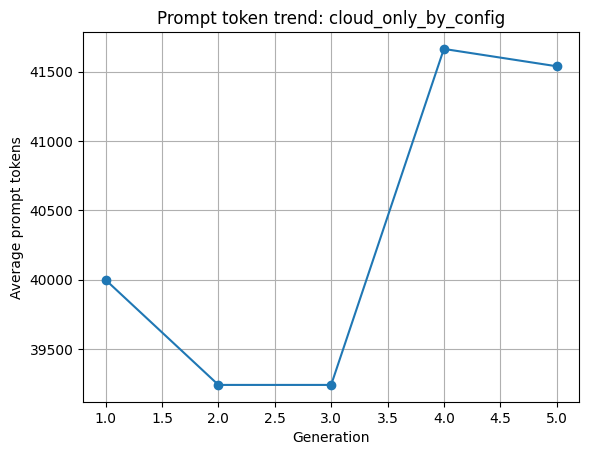

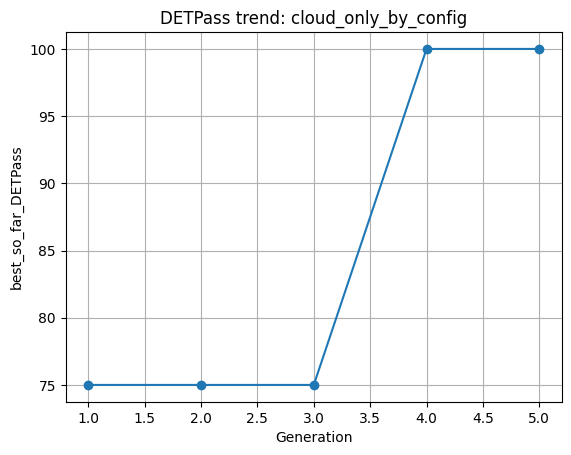

In [24]:
# ============================================================
# Cell 16. Token / DETPass trend plots and table
# ============================================================

import matplotlib.pyplot as plt

progress = load_progress(ANALYSIS_OUT_DIR)

if len(progress):
    cols = [c for c in [
        "generation", "validation_det_pass_rate", "validation_avg_det_score",
        "best_so_far_DETPass", "avg_prompt_tokens",
        "compression_ready", "compression_phase", "generation_phase", "next_action",
    ] if c in progress.columns]
    display(progress[cols])

    if "avg_prompt_tokens" in progress.columns:
        plt.figure()
        plt.plot(progress["generation"], pd.to_numeric(progress["avg_prompt_tokens"], errors="coerce"), marker="o")
        plt.xlabel("Generation")
        plt.ylabel("Average prompt tokens")
        plt.title(f"Prompt token trend: {ANALYSIS_MODE}")
        plt.grid(True)
        plt.show()

    det_col = "best_so_far_DETPass" if "best_so_far_DETPass" in progress.columns else "validation_det_pass_rate"
    if det_col in progress.columns:
        plt.figure()
        plt.plot(progress["generation"], pd.to_numeric(progress[det_col], errors="coerce"), marker="o")
        plt.xlabel("Generation")
        plt.ylabel(det_col)
        plt.title(f"DETPass trend: {ANALYSIS_MODE}")
        plt.grid(True)
        plt.show()
else:
    print("No progress CSV.")

In [25]:
# ============================================================
# Cell 17. Case A/B/C summary
# ============================================================

case_rows = []

if len(props_df):
    for case, g in props_df.groupby("case_label", dropna=False):
        case_rows.append({
            "source_table": "proposals",
            "case_label": case,
            "rows": len(g),
            "sources": ",".join(sorted(set(str(x) for x in g.get("source", pd.Series(dtype=str)).dropna()))),
            "operators": ", ".join(sorted(set(str(x) for x in g.get("operator", pd.Series(dtype=str)).dropna()))),
            "accepted_count": int((g.get("accepted") == True).sum()) if "accepted" in g.columns else np.nan,
            "rejected_count": int((g.get("accepted") == False).sum()) if "accepted" in g.columns else np.nan,
            "mean_expected_token_delta": pd.to_numeric(g.get("expected_token_delta"), errors="coerce").mean() if "expected_token_delta" in g.columns else np.nan,
            "mean_measured_prompt_token_delta": pd.to_numeric(g.get("measured_prompt_token_delta"), errors="coerce").mean() if "measured_prompt_token_delta" in g.columns else np.nan,
        })

if len(block_diff_df):
    for case, g in block_diff_df.groupby("case_label", dropna=False):
        case_rows.append({
            "source_table": "block_diffs",
            "case_label": case,
            "rows": len(g),
            "sources": ",".join(sorted(set(str(x) for x in g.get("source", pd.Series(dtype=str)).dropna()))),
            "operators": ", ".join(sorted(set(str(x) for x in g.get("mutation", pd.Series(dtype=str)).dropna()))),
            "accepted_count": np.nan,
            "rejected_count": np.nan,
            "mean_expected_token_delta": np.nan,
            "mean_measured_prompt_token_delta": np.nan,
        })

case_abc_summary_df = pd.DataFrame(case_rows)
display(case_abc_summary_df)

,source_table,case_label,rows,sources,operators,accepted_count,rejected_count,mean_expected_token_delta,mean_measured_prompt_token_delta
0,proposals,Case A: always-on micro,2,compression_fallback,"compress_candidate_strategies_to_minimal, temp...",2.0,0.0,-1353.000000,0.000000
1,proposals,Case B: threshold block,9,"cloudless,compression_fallback,det_feedback","add_targeted_repair_hint, compact_reasoning_sk...",9.0,0.0,-5.888889,-117.428571
2,proposals,Unclassified,10,advisor,,0.0,10.0,0.000000,NaN
3,block_diffs,Case A: always-on micro,2,,"compress_candidate_strategies_to_minimal, temp...",NaN,NaN,NaN,NaN
4,block_diffs,Case B: threshold block,9,,"compact_reasoning_skeleton, drop_optional_bloc...",NaN,NaN,NaN,NaN
5,block_diffs,Unclassified,4,,"add_targeted_repair_hint, strengthen_json_only...",NaN,NaN,NaN,NaN


In [ ]:
# ============================================================
# Cell 18. Three-way comparison
# ============================================================

comparison_rows = []

if "cloudless_out" in globals():
    comparison_rows.append(summarize_run(cloudless_out, "cloudless"))

if "hybrid_out" in globals():
    comparison_rows.append(summarize_run(hybrid_out, "cloud_advisor_hybrid"))

if "cloud_only_by_config_out" in globals():
    comparison_rows.append(summarize_run(cloud_only_by_config_out, "cloud_only_by_config"))

three_way_df = pd.DataFrame(comparison_rows)

if len(three_way_df):
    cols = [c for c in [
        "run_name", "best_so_far_DETPass", "validation_det_pass_rate", "validation_avg_det_score",
        "first_avg_prompt_tokens", "min_avg_prompt_tokens", "last_avg_prompt_tokens",
        "token_reduction_ratio_min", "token_reduction_ratio_last",
        "new_by_compression_sum", "new_by_compression_fallback_sum",
        "new_by_advisor_sum", "advisor_proposals_accepted_applied_sum",
        "advisor_rows", "advisor_accepted_rows", "advisor_rejected_rows",
        "fallback_rows", "block_diff_rows", "out_dir",
    ] if c in three_way_df.columns]
    display(three_way_df[cols])
else:
    print("No run variables found. Run at least one smoke.")

In [26]:
# ============================================================
# Cell 19. Final gates
# ============================================================

STRICT_GATE = False

def gate_cloud_only_by_config(out_dir):
    out_dir = Path(out_dir)
    errors = []
    warnings = []

    progress = load_progress(out_dir)
    trans = load_transitions(out_dir)
    props = proposal_table(out_dir)

    det_max = max(_max_col(progress, "best_so_far_DETPass"), _max_col(progress, "validation_det_pass_rate"), _max_col(progress, "det_pass_rate"))
    toks_max = _max_col(progress, "avg_prompt_tokens")

    fallback_sum = _sum_col(trans, "new_by_compression_fallback")
    local_micro = _sum_col(trans, "new_by_micro_compression")
    local_block = _sum_col(trans, "new_by_block_compression")
    advisor_sum = _sum_col(trans, "new_by_advisor")
    advisor_applied = _sum_col(trans, "advisor_proposals_accepted_applied")

    fallback_rows = int((props.get("source") == "compression_fallback").sum()) if len(props) and "source" in props.columns else 0
    advisor_rows = int((props.get("source") == "advisor").sum()) if len(props) and "source" in props.columns else 0
    advisor_accepted_rows = int((props.get("accepted") == True).sum()) if len(props) and "accepted" in props.columns else 0

    if det_max < 90:
        errors.append(f"DETPass below 90: {det_max}")
    if toks_max <= 0:
        errors.append("avg_prompt_tokens missing or non-positive")
    if fallback_sum > 0:
        errors.append(f"new_by_compression_fallback > 0: {fallback_sum}")
    if fallback_rows > 0:
        errors.append(f'source="compression_fallback" rows exist: {fallback_rows}')
    if advisor_rows <= 0:
        warnings.append("No advisor proposal rows found. This may mean advisor response schema was empty/rejected.")
    if advisor_sum <= 0 and advisor_applied <= 0 and advisor_accepted_rows <= 0:
        warnings.append("No advisor-applied child detected. This is not a successful advisor-only compression contribution.")

    result = {
        "out_dir": str(out_dir),
        "det_max": det_max,
        "tokens_max": toks_max,
        "new_by_compression_fallback": fallback_sum,
        "local_micro_sum": local_micro,
        "local_block_sum": local_block,
        "new_by_advisor": advisor_sum,
        "advisor_proposals_accepted_applied": advisor_applied,
        "fallback_rows": fallback_rows,
        "advisor_rows": advisor_rows,
        "advisor_accepted_rows": advisor_accepted_rows,
        "errors": errors,
        "warnings": warnings,
        "pass": len(errors) == 0,
        "successful_advisor_contribution": len(errors) == 0 and (advisor_sum > 0 or advisor_applied > 0 or advisor_accepted_rows > 0),
    }
    return result

gate_rows = []

if "cloud_only_by_config_out" in globals():
    g = gate_cloud_only_by_config(cloud_only_by_config_out)
    gate_rows.append({"run": "cloud_only_by_config", **g})

if "hybrid_out" in globals():
    gate_rows.append({"run": "cloud_advisor_hybrid", **summarize_run(hybrid_out, "cloud_advisor_hybrid")})

if "cloudless_out" in globals():
    gate_rows.append({"run": "cloudless", **summarize_run(cloudless_out, "cloudless")})

gate_df = pd.DataFrame(gate_rows)
display(gate_df)

if "cloud_only_by_config_out" in globals():
    g = gate_cloud_only_by_config(cloud_only_by_config_out)
    print("\n[CLOUD-ONLY-BY-CONFIG GATE]")
    print(json.dumps(g, ensure_ascii=False, indent=2))
    if STRICT_GATE and g["errors"]:
        raise RuntimeError("Cloud-only-by-config gate failed.")

,run,out_dir,det_max,tokens_max,new_by_compression_fallback,local_micro_sum,local_block_sum,new_by_advisor,advisor_proposals_accepted_applied,fallback_rows,advisor_rows,advisor_accepted_rows,errors,warnings,pass,successful_advisor_contribution
0,cloud_only_by_config,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_m...,100.0,41664.5,4.0,6.0,1.0,0.0,0.0,4,10,11,"[new_by_compression_fallback > 0: 4.0, source=...",[],False,False



[CLOUD-ONLY-BY-CONFIG GATE]
{
  "out_dir": "/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_cloud_only_by_config_A6000_SET_A_cloud_only_by_config_cat3456_lpc1_pop5_gens5_qwen25_coder_14b_20260611_220342/ga_output",
  "det_max": 100.0,
  "tokens_max": 41664.5,
  "new_by_compression_fallback": 4.0,
  "local_micro_sum": 6.0,
  "local_block_sum": 1.0,
  "new_by_advisor": 0.0,
  "advisor_proposals_accepted_applied": 0.0,
  "fallback_rows": 4,
  "advisor_rows": 10,
  "advisor_accepted_rows": 11,
  "errors": [
    "new_by_compression_fallback > 0: 4.0",
    "source=\"compression_fallback\" rows exist: 4"
  ],
  "warnings": [],
  "pass": false,
  "successful_advisor_contribution": false
}


In [ ]:
# ============================================================
# Cell 20. Optional full run commands
# ============================================================

RUN_FULL_CLOUD_ONLY_BY_CONFIG = False
RUN_FULL_THREE_WAY = False

FULL_COMMON_CONFIG = dict(
    model_key="qwen25_coder_14b",
    categories=tuple(range(1, 9)),
    limit_per_category=3,
    sample_size=24,
    validation_size=24,
    population=5,
    gens=10,
    target_detpass=90,
    full_run=True,
    progress="verbose",
    timeout_sec=3600,
    retries=0,
)

if RUN_FULL_CLOUD_ONLY_BY_CONFIG:
    full_cloud_only_by_config_out = run_ga_all_categories(
        **FULL_COMMON_CONFIG,
        base_prefix=f"full_cloud_only_by_config_{SERVER_PRESET}",
        use_advisor=True,
        mode_label="cloud_only_by_config",
        advisor_trigger_mode="always",
        advisor_min_population_for_child=4,
        advisor_force_child_quota=True,
        use_mock_advisor=False,
        cloud_only_by_config=True,
        **CLOUD_ONLY_BY_CONFIG_KWARGS,
    )
    inspect_run(full_cloud_only_by_config_out)
else:
    print("[SKIP] RUN_FULL_CLOUD_ONLY_BY_CONFIG=False")

if RUN_FULL_THREE_WAY:
    full_runs = {}
    for run_name, use_advisor, kwargs, cloud_only in [
        ("cloudless", False, HYBRID_COMPRESSION_KWARGS, False),
        ("cloud_advisor_hybrid", True, HYBRID_COMPRESSION_KWARGS, False),
        ("cloud_only_by_config", True, CLOUD_ONLY_BY_CONFIG_KWARGS, True),
    ]:
        out = run_ga_all_categories(
            **FULL_COMMON_CONFIG,
            base_prefix=f"full_three_way_{SERVER_PRESET}",
            use_advisor=use_advisor,
            mode_label=run_name,
            advisor_trigger_mode="always" if use_advisor else "off",
            advisor_min_population_for_child=4,
            advisor_force_child_quota=True if use_advisor else False,
            use_mock_advisor=False,
            cloud_only_by_config=cloud_only,
            **kwargs,
        )
        full_runs[run_name] = out
        inspect_run(out)
else:
    print("[SKIP] RUN_FULL_THREE_WAY=False")

In [5]:
# ============================================================
# Cell 21. Save paper artifacts
# ============================================================

ARTIFACT_DIR = SUMMARY_DIR / f"analysis_{SERVER_PRESET}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

if "three_way_df" in globals() and len(three_way_df):
    three_way_df.to_csv(ARTIFACT_DIR / "cloudless_vs_hybrid_vs_cloudonly_by_config.csv", index=False)

if "props_df" in globals() and len(props_df):
    props_df.to_csv(ARTIFACT_DIR / "proposal_table.csv", index=False)

if "block_diff_df" in globals() and len(block_diff_df):
    block_diff_df.to_csv(ARTIFACT_DIR / "before_after_block_diffs.csv", index=False)

if "case_abc_summary_df" in globals() and len(case_abc_summary_df):
    case_abc_summary_df.to_csv(ARTIFACT_DIR / "case_ABC_summary.csv", index=False)

if "prompt_summary_df" in globals() and len(prompt_summary_df):
    prompt_summary_df.to_csv(ARTIFACT_DIR / "advisor_prompt_summary.csv", index=False)

if "advisor_response_df" in globals() and len(advisor_response_df):
    advisor_response_df.to_csv(ARTIFACT_DIR / "advisor_response_summary.csv", index=False)

# Save markdown snippets.
md_lines = []
md_lines.append("# Advisor Prompt / Dataset Feedback Analysis\n")
md_lines.append(f"- server: {SERVER_PRESET}\n")
md_lines.append(f"- analysis_mode: {globals().get('ANALYSIS_MODE', None)}\n")
md_lines.append(f"- analysis_out_dir: {globals().get('ANALYSIS_OUT_DIR', None)}\n")
if "dataset_feedback" in globals():
    md_lines.append("\n## Reconstructed dataset feedback\n")
    md_lines.append("```json\n" + json.dumps(dataset_feedback, ensure_ascii=False, indent=2)[:8000] + "\n```\n")
if "prompt_summary_df" in globals() and len(prompt_summary_df):
    md_lines.append("\n## Advisor prompt files\n")
    md_lines.append(prompt_summary_df.to_markdown(index=False))
    md_lines.append("\n")
(ARTIFACT_DIR / "advisor_prompt_sections_and_dataset_feedback.md").write_text("\n".join(md_lines), encoding="utf-8")

print("=" * 120)
print("[SAVED PAPER ARTIFACTS]")
print("=" * 120)
for p in sorted(ARTIFACT_DIR.glob("*")):
    print(p)

[SAVED PAPER ARTIFACTS]
/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts/cloud_only_by_config/analysis_A6000_SET_A_20260612_011848/advisor_prompt_sections_and_dataset_feedback.md


In [6]:
# ============================================================
# Cell 22. Interpretation template
# ============================================================

def interpretation_template():
    if "three_way_df" in globals() and len(three_way_df):
        comp = three_way_df.copy()
    else:
        comp = pd.DataFrame()

    mode = globals().get("ANALYSIS_MODE", "unknown")
    out_dir = globals().get("ANALYSIS_OUT_DIR", "unknown")

    lines_ko = []
    lines_ko.append("## 한국어 해석 템플릿")
    lines_ko.append("")
    lines_ko.append(f"분석 대상 run은 `{mode}`이며 output directory는 `{out_dir}`이다.")
    lines_ko.append("본 notebook은 cloudless, hybrid advisor, cloud-only-by-config를 분리하여 prompt compression 기여를 분석한다.")
    lines_ko.append("")
    lines_ko.append("핵심 해석 기준은 다음과 같다.")
    lines_ko.append("- `source=\"compression_fallback\"`가 존재하면 순수 cloud-only advisor 기여로 주장하지 않는다.")
    lines_ko.append("- `advisor_accepted_rows` 또는 `advisor_proposals_accepted_applied`가 양수이고, measured token delta가 음수일 때 advisor 기반 compression 기여로 볼 수 있다.")
    lines_ko.append("- `DETPass`가 threshold 이상으로 유지되어야 성능 보존 compression으로 볼 수 있다.")
    lines_ko.append("- Case A는 작은 genome/parameter 압축, Case B는 block 단위 압축, Case C는 multi/global 압축으로 해석한다.")
    lines_ko.append("")
    if "dataset_feedback" in globals():
        lines_ko.append("Dataset feedback 요약:")
        lines_ko.append(f"- best_so_far_DETPass: {dataset_feedback.get('best_so_far_DETPass')}")
        lines_ko.append(f"- validation_det_pass_rate: {dataset_feedback.get('validation_det_pass_rate')}")
        lines_ko.append(f"- token_trend: {dataset_feedback.get('token_trend')}")
        lines_ko.append(f"- top_failures: {dataset_feedback.get('top_failures')[:3]}")
    lines_ko.append("")
    lines_ko.append("## English interpretation template")
    lines_ko.append("")
    lines_ko.append(f"The analyzed run is `{mode}`, with output directory `{out_dir}`.")
    lines_ko.append("This notebook separates cloudless, hybrid advisor, and cloud-only-by-config settings to avoid attributing fallback compression to the cloud advisor.")
    lines_ko.append("A cloud-advisor-only contribution should be claimed only when fallback rows are absent and accepted/applied advisor proposals produce measurable prompt-token reduction while preserving DETPass.")
    return "\n".join(lines_ko)

text = interpretation_template()
print(text)

if "ARTIFACT_DIR" in globals():
    (ARTIFACT_DIR / "interpretation_template.md").write_text(text, encoding="utf-8")
    print("\nsaved:", ARTIFACT_DIR / "interpretation_template.md")

## 한국어 해석 템플릿

분석 대상 run은 `unknown`이며 output directory는 `unknown`이다.
본 notebook은 cloudless, hybrid advisor, cloud-only-by-config를 분리하여 prompt compression 기여를 분석한다.

핵심 해석 기준은 다음과 같다.
- `source="compression_fallback"`가 존재하면 순수 cloud-only advisor 기여로 주장하지 않는다.
- `advisor_accepted_rows` 또는 `advisor_proposals_accepted_applied`가 양수이고, measured token delta가 음수일 때 advisor 기반 compression 기여로 볼 수 있다.
- `DETPass`가 threshold 이상으로 유지되어야 성능 보존 compression으로 볼 수 있다.
- Case A는 작은 genome/parameter 압축, Case B는 block 단위 압축, Case C는 multi/global 압축으로 해석한다.


## English interpretation template

The analyzed run is `unknown`, with output directory `unknown`.
This notebook separates cloudless, hybrid advisor, and cloud-only-by-config settings to avoid attributing fallback compression to the cloud advisor.
A cloud-advisor-only contribution should be claimed only when fallback rows are absent and accepted/applied advisor proposals produce measurable prompt-token reduction while preserving DETPass.

saved: /ho

In [10]:
# ============================================================
# Feedback -> Advisor Prompt -> Proposal -> Next Generation Effect
# ============================================================

from pathlib import Path
import json
import re
import pandas as pd
import numpy as np

OUT_DIR = Path(cloud_only_by_config_out)  # cloud-only-by-config 결과만 분석
print("OUT_DIR:", OUT_DIR)

def read_json(path):
    path = Path(path)
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8", errors="replace"))
    except Exception:
        return {}

def read_jsonl(path):
    rows = []
    path = Path(path)
    if not path.exists():
        return rows
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        if not line.strip():
            continue
        try:
            rows.append(json.loads(line))
        except Exception:
            rows.append({"_raw": line, "_parse_error": True})
    return rows

def extract_gen_from_name(path):
    m = re.search(r"generation_(\d+)", Path(path).name)
    return int(m.group(1)) if m else None

progress = pd.read_csv(OUT_DIR / "ga_generation_progress.csv")
trans = pd.read_csv(OUT_DIR / "population_transitions.csv")

# generation별 progress
p = progress.copy()
for col in ["generation", "best_so_far_DETPass", "validation_det_pass_rate", "validation_avg_det_score", "avg_prompt_tokens"]:
    if col not in p.columns:
        p[col] = np.nan

p_small = p[[
    "generation",
    "best_so_far_DETPass",
    "validation_det_pass_rate",
    "validation_avg_det_score",
    "avg_prompt_tokens",
    "compression_ready",
    "compression_phase",
]].copy()

p_small["next_generation"] = p_small["generation"] + 1

# next generation effect
next_p = p_small[[
    "generation",
    "best_so_far_DETPass",
    "validation_det_pass_rate",
    "validation_avg_det_score",
    "avg_prompt_tokens",
]].copy()

next_p = next_p.rename(columns={
    "generation": "next_generation",
    "best_so_far_DETPass": "next_best_so_far_DETPass",
    "validation_det_pass_rate": "next_validation_det_pass_rate",
    "validation_avg_det_score": "next_validation_avg_det_score",
    "avg_prompt_tokens": "next_avg_prompt_tokens",
})

timeline = p_small.merge(next_p, on="next_generation", how="left")

timeline["delta_tokens_next"] = timeline["next_avg_prompt_tokens"] - timeline["avg_prompt_tokens"]
timeline["delta_DETPass_next"] = timeline["next_best_so_far_DETPass"] - timeline["best_so_far_DETPass"]

# transition 정보 붙이기
trans_cols = [
    "generation",
    "new_by_advisor",
    "advisor_proposals_generated",
    "advisor_proposals_accepted_applied",
    "advisor_proposals_rejected",
    "advisor_children_scheduled",
    "advisor_compression_children_scheduled",
    "new_by_compression_fallback",
    "new_by_compression",
    "new_by_micro_compression",
    "new_by_block_compression",
    "new_by_multi_block_compression",
]
trans_cols = [c for c in trans_cols if c in trans.columns]

timeline = timeline.merge(trans[trans_cols], on="generation", how="left")

print("=" * 120)
print("[GENERATION CAUSAL TIMELINE]")
print("=" * 120)
display(timeline)

NameError: name 'cloud_only_by_config_out' is not defined

In [9]:
# ============================================================
# Inspect dataset feedback / advisor batch / exact prompt by generation
# ============================================================

def compact_keys(obj, max_depth=2, prefix=""):
    keys = []
    if max_depth < 0:
        return keys
    if isinstance(obj, dict):
        for k, v in obj.items():
            kk = f"{prefix}.{k}" if prefix else str(k)
            keys.append(kk)
            keys.extend(compact_keys(v, max_depth=max_depth-1, prefix=kk))
    elif isinstance(obj, list) and obj:
        keys.extend(compact_keys(obj[0], max_depth=max_depth-1, prefix=prefix + "[]"))
    return keys

feedback_rows = read_jsonl(OUT_DIR / "structured_feedback.jsonl")
advisor_batches = read_jsonl(OUT_DIR / "advisor_feedback_batches.jsonl")

print("=" * 120)
print("[STRUCTURED FEEDBACK]")
print("=" * 120)
print("rows:", len(feedback_rows))
if feedback_rows:
    print("sample keys:", compact_keys(feedback_rows[0])[:80])
    display(pd.DataFrame(feedback_rows[:10]))

print("\n" + "=" * 120)
print("[ADVISOR FEEDBACK BATCHES]")
print("=" * 120)
print("rows:", len(advisor_batches))
if advisor_batches:
    print("sample keys:", compact_keys(advisor_batches[0])[:100])
    display(pd.DataFrame(advisor_batches[:5]))

print("\n" + "=" * 120)
print("[ADVISOR PROMPT FILES]")
print("=" * 120)

prompt_files = sorted(OUT_DIR.glob("advisor_prompt_generation_*.txt"))
for pth in prompt_files:
    text = pth.read_text(encoding="utf-8", errors="replace")
    print(pth.name, "chars:", len(text), "approx_tokens:", round(len(text) / 4))

NameError: name 'read_jsonl' is not defined

In [8]:
# ============================================================
# Show one generation: feedback prompt -> advisor response -> proposals
# ============================================================

def show_generation_advisor_trace(gen: int, max_prompt_lines=220):
    print("=" * 120)
    print(f"[GENERATION {gen} ADVISOR TRACE]")
    print("=" * 120)

    # 1) prompt
    prompt_path = OUT_DIR / f"advisor_prompt_generation_{gen:03d}.txt"
    if prompt_path.exists():
        text = prompt_path.read_text(encoding="utf-8", errors="replace")
        lines = text.splitlines()

        keywords = [
            "feedback",
            "failure",
            "diagnostic",
            "DETPass",
            "detpass",
            "compression_policy",
            "compression_ready",
            "prompt_token_breakdown",
            "block_token_breakdown",
            "Case A",
            "Case B",
            "Case C",
            "few_shot",
            "candidate_strategies",
            "selected_block",
            "block_compression",
            "proposal",
        ]

        hit = []
        for i, line in enumerate(lines):
            low = line.lower()
            if any(k.lower() in low for k in keywords):
                hit.append(i)

        selected = set()
        for i in hit:
            for j in range(max(0, i - 2), min(len(lines), i + 4)):
                selected.add(j)

        selected = sorted(selected)

        print("\n[ADVISOR PROMPT KEY SECTIONS]")
        print("file:", prompt_path.name)
        print("chars:", len(text), "approx_tokens:", round(len(text) / 4))
        print("-" * 120)

        for i in selected[:max_prompt_lines]:
            print(f"{i+1:04d}: {lines[i]}")

        if len(selected) > max_prompt_lines:
            print(f"... truncated {len(selected) - max_prompt_lines} selected lines")
    else:
        print("[WARN] prompt file not found:", prompt_path)

    # 2) response
    response_path = OUT_DIR / f"advisor_response_generation_{gen:03d}.json"
    print("\n" + "=" * 120)
    print("[ADVISOR RESPONSE]")
    print("=" * 120)

    if response_path.exists():
        obj = read_json(response_path)
        print("file:", response_path.name)
        print("top keys:", list(obj.keys()))

        parsed = obj.get("parsed", {})
        print("parsed type:", type(parsed).__name__)
        if isinstance(parsed, dict):
            print("parsed keys:", list(parsed.keys()))

        print("accepted_proposals:", len(obj.get("accepted_proposals", []) or []))
        print("rejected_proposals:", len(obj.get("rejected_proposals", []) or []))

        raw = str(obj.get("raw_content", ""))
        print("\n[raw_content head]")
        print(raw[:3000])
    else:
        print("[WARN] response file not found:", response_path)

    # 3) normalized advisor proposals
    adv_rows = []
    for r in read_jsonl(OUT_DIR / "advisor_mutation_proposals.jsonl"):
        if int(r.get("generation", -1) or -1) == gen:
            adv_rows.append(r)

    print("\n" + "=" * 120)
    print("[NORMALIZED ADVISOR PROPOSALS]")
    print("=" * 120)
    print("rows:", len(adv_rows))

    if adv_rows:
        df = pd.DataFrame(adv_rows)
        cols = [
            "generation",
            "proposal_id",
            "schema_source",
            "mutation_family",
            "compression_level",
            "case_label",
            "operator",
            "mutation_type",
            "target_block_id",
            "selected_block_id",
            "selected_block_ids",
            "expected_token_delta",
            "measured_prompt_token_delta",
            "accepted",
            "rejection_reason",
            "fallback_reason",
            "dataset_feedback_reason",
        ]
        display(df[[c for c in cols if c in df.columns]])

    # 4) actual scheduled mutation proposals
    mut_rows = []
    for r in read_jsonl(OUT_DIR / "mutation_proposals.jsonl"):
        if int(r.get("generation", -1) or -1) in [gen, gen + 1]:
            mut_rows.append(r)

    print("\n" + "=" * 120)
    print("[ACTUAL MUTATION PROPOSALS AROUND THIS GENERATION]")
    print("=" * 120)
    print("rows:", len(mut_rows))
    if mut_rows:
        df = pd.DataFrame(mut_rows)
        cols = [
            "generation",
            "source",
            "mutation_family",
            "compression_level",
            "case_label",
            "operator",
            "mutation_type",
            "target_block_id",
            "selected_block_id",
            "expected_token_delta",
            "measured_prompt_token_delta",
            "accepted",
            "rejection_reason",
            "fallback_reason",
        ]
        display(df[[c for c in cols if c in df.columns]])

# 원하는 generation 번호로 변경
show_generation_advisor_trace(1)

[GENERATION 1 ADVISOR TRACE]


NameError: name 'OUT_DIR' is not defined

In [7]:
# ============================================================
# Block/genome before-after diff + next generation metric
# ============================================================

block_diff_rows = read_jsonl(OUT_DIR / "ga_block_diffs.jsonl")

parsed_rows = []
for obj in block_diff_rows:
    gen = obj.get("generation", obj.get("gen"))
    if "changed" in obj and isinstance(obj["changed"], list):
        changes = obj["changed"]
    elif "changes" in obj and isinstance(obj["changes"], list):
        changes = obj["changes"]
    elif "diffs" in obj and isinstance(obj["diffs"], list):
        changes = obj["diffs"]
    else:
        changes = [obj]

    for ch in changes:
        if not isinstance(ch, dict):
            continue
        parsed_rows.append({
            "generation": ch.get("generation", gen),
            "block": ch.get("block", ch.get("block_id", ch.get("target_block_id"))),
            "mutation": ch.get("mutation", ch.get("operator", ch.get("mutation_type"))),
            "old": ch.get("old"),
            "new": ch.get("new"),
            "source": ch.get("source"),
            "compression_level": ch.get("compression_level"),
            "proposal_id": ch.get("proposal_id"),
        })

diff_df = pd.DataFrame(parsed_rows)

print("=" * 120)
print("[BLOCK / GENOME BEFORE-AFTER DIFFS]")
print("=" * 120)
print("rows:", len(diff_df))
if len(diff_df):
    display(diff_df)

# progress와 연결
progress = pd.read_csv(OUT_DIR / "ga_generation_progress.csv").copy()

for c in ["generation", "best_so_far_DETPass", "validation_det_pass_rate", "avg_prompt_tokens"]:
    if c not in progress.columns:
        progress[c] = np.nan

metric = progress[[
    "generation",
    "best_so_far_DETPass",
    "validation_det_pass_rate",
    "avg_prompt_tokens",
]].copy()

metric_next = metric.rename(columns={
    "generation": "next_generation",
    "best_so_far_DETPass": "next_best_so_far_DETPass",
    "validation_det_pass_rate": "next_validation_det_pass_rate",
    "avg_prompt_tokens": "next_avg_prompt_tokens",
})

metric["next_generation"] = metric["generation"] + 1
metric = metric.merge(metric_next, on="next_generation", how="left")

metric["delta_tokens_next"] = metric["next_avg_prompt_tokens"] - metric["avg_prompt_tokens"]
metric["delta_DETPass_next"] = metric["next_best_so_far_DETPass"] - metric["best_so_far_DETPass"]

print("\n" + "=" * 120)
print("[GENERATION METRIC BEFORE -> NEXT]")
print("=" * 120)
display(metric)

NameError: name 'read_jsonl' is not defined